<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/bioprocesses/biomass_to_sustainable_aviation_fuel_with_neqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biomass to sustainable aviation fuel (SAF) with NeqSim

**A concept-screening notebook for HEFA, gasification–Fischer–Tropsch,
alcohol-to-jet, fast pyrolysis, hydrothermal liquefaction (HTL), and a
biogenic-$CO_2$ plus green-$H_2$ hybrid route.**

The notebook combines process theory, transparent mass and energy balances,
NeqSim phase-equilibrium and compression calculations, carbon and hydrogen
accounting, logistics, literature economics, lifecycle data, uncertainty,
and a decision matrix.

**Engineering status:** educational concept screening, not a licensed design,
ASTM fuel qualification, CORSIA certification, or investment estimate.


## Learning outcomes and notebook map

After working through the notebook you should be able to:

1. distinguish feedstock, conversion, upgrading, blending, and certification;
2. derive useful first-pass yields from ultimate analysis and stoichiometry;
3. use NeqSim for syngas cooling, three-phase product separation, and
   compression-train calculations;
4. compare routes on SAF yield, carbon efficiency, energy efficiency,
   hydrogen use, lifecycle intensity, cost, maturity, and supply-chain scale;
5. replace the embedded teaching data with public databases or project data;
6. identify which questions require specialist gasification, reactor,
   refinery-assay, fuel-property, lifecycle, or cost models.

The calculation basis is normally **1,000 kg dry feedstock**. All pressures
used in NeqSim are absolute (`bara`) and all energy values are lower-heating-
value based unless explicitly stated.


## 1. System boundary and concepts

A fair comparison must keep three boundaries separate:

- **Plant balance:** feedstock gate to neat SAF blend component and coproducts.
- **Lifecycle balance:** cultivation/collection, transport, conversion,
  hydrogen/electricity, distribution, combustion, land-use effects, and credits.
- **Fuel qualification:** composition and properties required by the applicable
  fuel specification and approved production pathway.

The six concepts are deliberately different. HEFA begins with lipids;
gasification–FT uses most organic matter; ATJ passes through an alcohol; fast
pyrolysis makes an oxygen-rich bio-oil from relatively dry feed; HTL makes a
distinct biocrude in compressed hot water from wet feed; and the hybrid route
recycles biogenic $CO_2$ with electrolytic hydrogen. No single route is best
on every axis.


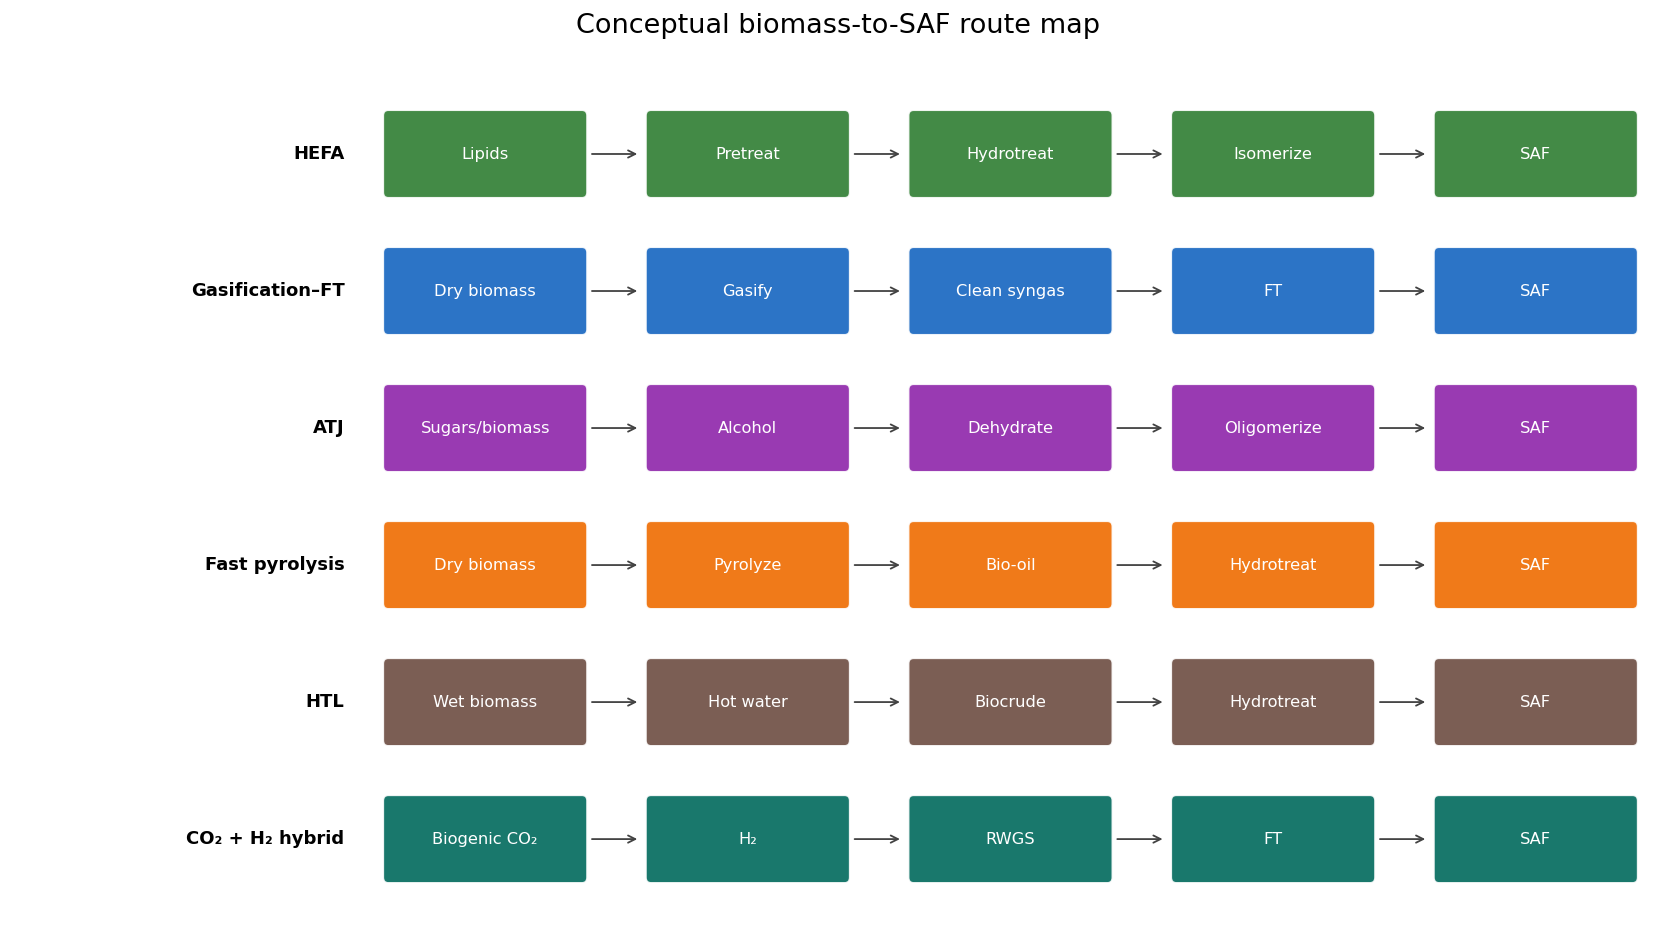

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

routes = {
    "HEFA": ["Lipids", "Pretreat", "Hydrotreat", "Isomerize", "SAF"],
    "Gasification–FT": ["Dry biomass", "Gasify", "Clean syngas", "FT", "SAF"],
    "ATJ": ["Sugars/biomass", "Alcohol", "Dehydrate", "Oligomerize", "SAF"],
    "Fast pyrolysis": ["Dry biomass", "Pyrolyze", "Bio-oil", "Hydrotreat", "SAF"],
    "HTL": ["Wet biomass", "Hot water", "Biocrude", "Hydrotreat", "SAF"],
    "CO₂ + H₂ hybrid": ["Biogenic CO₂", "H₂", "RWGS", "FT", "SAF"],
}

fig, ax = plt.subplots(figsize=(13, 7.4))
colors = ["#2E7D32", "#1565C0", "#8E24AA", "#EF6C00", "#6D4C41", "#00695C"]
for row, ((route, steps), color) in enumerate(zip(routes.items(), colors)):
    y_position = 5.5 - row
    ax.text(-0.35, y_position, route, ha="right", va="center", weight="bold")
    for column, step in enumerate(steps):
        x_position = column * 2.1
        box = FancyBboxPatch(
            (x_position, y_position - 0.28),
            1.55,
            0.56,
            boxstyle="round,pad=0.04",
            facecolor=color,
            edgecolor="white",
            alpha=0.90,
        )
        ax.add_patch(box)
        ax.text(
            x_position + 0.775,
            y_position,
            step,
            color="white",
            ha="center",
            va="center",
            fontsize=9,
        )
        if column < len(steps) - 1:
            ax.annotate(
                "",
                xy=(x_position + 2.02, y_position),
                xytext=(x_position + 1.60, y_position),
                arrowprops={"arrowstyle": "->", "color": "#424242"},
            )
ax.set_xlim(-3.0, 10.2)
ax.set_ylim(-0.2, 6.2)
ax.axis("off")
ax.set_title("Conceptual biomass-to-SAF route map", fontsize=15, pad=14)
plt.tight_layout()
plt.show()


## 2. Evidence, versions, and source hierarchy

The technical pathway descriptions are anchored in the
[ICAO CORSIA default lifecycle document (November 2025)](https://www.icao.int/sites/default/files/environmental-protection/CORSIA/Documents/CORSIA%20Eligible%20Fuels/ICAO-document-06-Default-Life-Cycle-Emissions-November-2025.pdf),
the [IEA Bioenergy Task 39 SAF report](https://task39.ieabioenergy.com/wp-content/uploads/sites/37/2024/05/IEA-Bioenergy-Task-39-SAF-report.pdf),
and the [U.S. DOE SAF Initiative](https://www.energy.gov/cmei/fuels/sustainable-aviation-fuel-initiative).

NeqSim is used for fluid thermodynamics and process equipment, not for solid
biomass chemistry or catalyst kinetics. The released
[NeqSim Python 3.18.0](https://pypi.org/project/neqsim/) package supplies the
Python/JPype bridge. The calculation runtime is built from the current
`equinor/neqsim` `master` branch, and the resolved commit, JAR hash, class
location, Python version, and Java version are recorded below. A clean local
validation may provide the same checked-out commit and source-built JAR through
`NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR`.

**Evidence ladder used here:** official pathway/LCA tables; published review
bounds; atom, mass, and energy conservation; then qualitative trend checks.
Values marked *illustrative* are scenario assumptions, not literature claims.


In [2]:
import hashlib
import importlib.metadata
import importlib.util
import math
import os
import platform
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        if isinstance(value, pd.DataFrame):
            print(value.to_string(index=False))
        else:
            print(value)

NEQSIM_PIN = "3.18.0"
NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

bridge_is_ready = False
try:
    bridge_is_ready = importlib.metadata.version("neqsim") == NEQSIM_PIN
except importlib.metadata.PackageNotFoundError:
    pass

if not bridge_is_ready and SOURCE_JAR_OVERRIDE is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", f"neqsim=={NEQSIM_PIN}"],
        check=True,
    )

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    neqsim_jar = Path(SOURCE_JAR_OVERRIDE).resolve()
    source_build_method = os.environ.get(
        "NEQSIM_SOURCE_BUILD_METHOD",
        "prebuilt from the checked-out source commit",
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master build did not produce a runtime JAR."
        )
    neqsim_jar = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    source_build_method = "Maven package from the resolved master commit"

if not neqsim_jar.is_file():
    raise FileNotFoundError(f"NeqSim source JAR not found: {neqsim_jar}")

NEQSIM_SOURCE_JAR_SHA256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

provenance_source = r'''
import neqsim.process.dynamics.DynamicCapabilityReport;

public class NeqsimSourceProvenance {
  public static void main(String[] args) {
    System.out.println(
        DynamicCapabilityReport.class.getProtectionDomain()
            .getCodeSource().getLocation());
  }
}
'''
provenance_java = Path(tempfile.gettempdir()) / "NeqsimSourceProvenance.java"
provenance_java.write_text(provenance_source, encoding="utf-8")
location_result = subprocess.run(
    [
        "java",
        "--class-path",
        str(neqsim_jar),
        str(provenance_java),
    ],
    check=True,
    capture_output=True,
    text=True,
)
LOADED_JAR_LOCATION = location_result.stdout.strip()
assert neqsim_jar.name in LOADED_JAR_LOCATION

# Colab also verifies the bridge path with jpype.addClassPath before import.
if importlib.util.find_spec("jpype") and importlib.util.find_spec("neqsim"):
    import jpype

    if jpype.isJVMStarted():
        raise RuntimeError(
            "The JVM started before the source JAR was selected. "
            "Restart the runtime and run all cells."
        )
    jpype.addClassPath(str(neqsim_jar))
    from neqsim.neqsimpython import init_jvm

    init_jvm()
    MAIN_ONLY_CLASS = jpype.JClass(
        "neqsim.process.dynamics.DynamicCapabilityReport"
    )
    jpype_location = str(
        MAIN_ONLY_CLASS.class_.getProtectionDomain()
            .getCodeSource().getLocation()
    )
    assert neqsim_jar.name in jpype_location

java_version = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]
print(f"NeqSim Python bridge target: {NEQSIM_PIN}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {NEQSIM_SOURCE_JAR_SHA256}")
print(f"NeqSim source build method: {source_build_method}")
print(f"Loaded main-only class from: {LOADED_JAR_LOCATION}")
print(f"Python: {platform.python_version()}; Java: {java_version}")
print(f"Pandas: {pd.__version__}; NumPy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")


NeqSim Python bridge target: 3.18.0
NeqSim source ref: master
NeqSim source commit: 4a8eb2ae725acd6727098e62b07abaadb74ddeeb
NeqSim source JAR SHA-256: 2d15c411bab7f97a25c419b9bb256fb3fdcac226b8c5b5ad2da1d28a239e6004
NeqSim source build method: offline javac source overlay on the v3.18.0 release dependency bundle
Loaded main-only class from: file:/workspace/scratch/62ebdac6e5b4/neqsim-master-4a8eb2ae-runtime.jar
Python: 3.12.13; Java: openjdk version "17.0.19" 2026-04-21
Pandas: 2.2.3; NumPy: 2.3.5
Matplotlib: 3.10.8


In [3]:
provenance = pd.DataFrame(
    [
        [
            "NeqSim",
            f"bridge {NEQSIM_PIN}; master {NEQSIM_SOURCE_COMMIT[:12]}",
            "Phase behavior and process equipment",
        ],
        ["ICAO CORSIA", "8th edition, 19 Nov 2025", "Pathways and core LCA values"],
        ["IEA Bioenergy T39", "2024 report", "Technology status and constraints"],
        ["Phyllis2", "Accessed conceptually", "Feedstock-property replacement data"],
        ["Embedded dataset", "Teaching snapshot", "Fully reproducible clean run"],
    ],
    columns=["Source", "Version or date", "Use in this notebook"],
)
display(provenance)


           Source                    Version or date                 Use in this notebook
           NeqSim bridge 3.18.0; master 4a8eb2ae725a Phase behavior and process equipment
      ICAO CORSIA           8th edition, 19 Nov 2025         Pathways and core LCA values
IEA Bioenergy T39                        2024 report    Technology status and constraints
         Phyllis2              Accessed conceptually  Feedstock-property replacement data
 Embedded dataset                  Teaching snapshot         Fully reproducible clean run


### Source register and interpretation rules

Every numerical input used below has an origin code. `LIT-*` means a value
transcribed from the cited literature; `DER-*` means a calculation from cited
values and a shown equation; `SCN-*` means an explicit, editable teaching
scenario rather than a literature claim. This distinction is essential: a
source can support a process family without supporting every assumed stream
composition or product cut.

| ID | Open source | Numerical data used in this notebook |
|---|---|---|
| LIT-ICAO-2025 | [ICAO CORSIA default lifecycle emissions, Nov. 2025](https://www.icao.int/sites/default/files/environmental-protection/CORSIA/Documents/CORSIA%20Eligible%20Fuels/ICAO-document-06-Default-Life-Cycle-Emissions-November-2025.pdf) | Approved pathway mapping; selected core-LCA defaults; 89 g $CO_2$e/MJ fossil comparator |
| LIT-IEA-T39-2024 | [IEA Bioenergy Task 39 SAF report](https://task39.ieabioenergy.com/wp-content/uploads/sites/37/2024/05/IEA-Bioenergy-Task-39-SAF-report.pdf) | HEFA jet-range discussion; FT straight-run jet constraint; ATJ and PtL status |
| LIT-PNNL-PYRO-2009 | [PNNL-18284 Rev. 1](https://www.pnnl.gov/main/publications/external/technical_reports/PNNL-18284rev1.pdf) | Hybrid-poplar analysis; 520 °C pyrolysis; oil/water/char/gas yields; upgrading conditions |
| LIT-PNNL-PYRO-2014 | [PNNL-24176](https://www.pnnl.gov/main/publications/external/technical_reports/pnnl-24176.pdf) | 62 wt% organic oil; 87 GGE/dry US ton; 47% carbon efficiency; three-step hydrotreating; TEA and water data |
| LIT-PNNL-HTL-2024 | [PNNL-37230](https://www.pnnl.gov/main/publications/external/technical_reports/PNNL-37230.pdf) | 15 wt% slurry; 338 °C/2,800 psig experiment; product yields; biocrude assay; scenario fuel yields and TEA |
| LIT-DOE-SAFFIRE-2023 | [DOE Project SAFFiRE peer review](https://www.energy.gov/sites/default/files/2023-05/beto-03-project-peer-review-sdi-sup-apr-2023-yancey.pdf) | 80 US gal ethanol/dry US ton corn stover design goal |
| LIT-NREL-BIOJET-2016 | [NREL review of biojet conversion technologies](https://docs.nrel.gov/docs/fy16osti/66291.pdf) | Route chemistry, upgrading sequence, maturity, and limitations |
| LIT-NREL-HEFA-2024 | [NREL HEFA state-of-industry report](https://www.osti.gov/biblio/2426563) | Commercial status, lipid feedstocks, process configuration, and cost drivers |
| LIT-NREL-TEA-2016 | [Comparative TEA, Tan et al.](https://www.osti.gov/pages/biblio/1340652) | Common 2,000 dry metric t/day comparison basis and cost-method context |
| LIT-NREL-ETJ-2016 | [Ethanol-to-jet TEA, Tao et al.](https://www.osti.gov/pages/biblio/1345118) | ATJ process and cost-driver context |
| DATA-PUBCHEM-TRIOLEIN | [PubChem triolein record](https://pubchem.ncbi.nlm.nih.gov/compound/Triolein) | Molecular formula used for the HEFA stoichiometric surrogate |
| DATA-DOE-H2 | [U.S. DOE hydrogen-storage basics](https://www.energy.gov/cmei/fuels/hydrogen-storage) | Hydrogen gravimetric-energy context; 120 MJ/kg LHV used here |
| LIT-GREET-2025 | [Argonne R&D GREET versions](https://greet.anl.gov/greet/versions.html) | Versioned lifecycle inventories and SAF pathways |
| DATA-PHYLLIS2 | [JRC/ECN Phyllis2](https://knowledge4policy.ec.europa.eu/dataset/beo-ecnphyllis_en) | Ultimate/proximate analyses and heating values; approximately 3,000 records |
| DATA-ENSPRESO | [JRC ENSPRESO biomass](https://data.jrc.ec.europa.eu/dataset/74ed5a04-7d74-4807-9eab-b94774309d9f) | EU regional biomass potentials, 2010–2050; downloadable XLSX; CC BY 4.0 |
| DATA-FAOSTAT | [FAOSTAT](https://www.fao.org/faostat/en/) | Agricultural and forestry production/trade |
| DATA-EUROSTAT | [Eurostat API guide](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-getting-started) | EU statistics, energy, agriculture, waste, and prices |
| DATA-NREL-LOGISTICS | [NREL SAF logistics report](https://www.osti.gov/biblio/2440801) | Transport, terminal, blending, and airport supply-chain choices |
| DOC-NEQSIM-OIL-QUALITY | [NeqSim oil-quality standards](https://equinor.github.io/neqsim/standards/oil_quality_standards.html) | ASTM D86, D445, D4052, D4294, D6377, D4737, D611, D1322, D2500, D97, D3230, TVP, EN 116, and BS&W implementation scope |
| LIT-PNNL-HTL-2013 | [PNNL-22314 algae HTL design case](https://www.pnnl.gov/main/publications/external/technical_reports/PNNL-22314.pdf) | Whole-wet-algae HTL process basis near 300–350 °C and 2,000–3,000 psia |
| LIT-PNNL-SLUDGE-2016 | [PNNL-25464 Rev. 1](https://www.pnnl.gov/main/publications/external/technical_reports/PNNL-25464Rev1.pdf) | Sludge HTL, biocrude upgrading, carbon efficiency, and electricity use |

The register is a broad map of the major open, authoritative datasets and
design reports needed for a concept study. It cannot literally enumerate all
articles ever published. For an auditable systematic review, add Scopus, Web
of Science, Crossref, or OpenAlex searches with a frozen query, screening log,
DOI list, and retrieval date. Proprietary ASTM text and commercial databases
require their licences.


In [4]:
source_registry = pd.DataFrame(
    [
        ["LIT-ICAO-2025", "literature", "ICAO document 06, 8th ed., 19 Nov 2025"],
        ["LIT-IEA-T39-2024", "literature", "IEA Bioenergy Task 39 SAF report"],
        ["LIT-PNNL-PYRO-2009", "literature", "PNNL-18284 Rev. 1"],
        ["LIT-PNNL-PYRO-2014", "literature", "PNNL-24176"],
        ["LIT-PNNL-HTL-2024", "literature", "PNNL-37230"],
        ["LIT-DOE-SAFFIRE-2023", "literature", "DOE BETO Project SAFFiRE"],
        ["DATA-PUBCHEM-TRIOLEIN", "database", "PubChem triolein formula"],
        ["DATA-DOE-H2", "database", "U.S. DOE hydrogen-storage basics"],
        [
            "DOC-NEQSIM-OIL-QUALITY",
            "documentation",
            "NeqSim oil-quality standards guide",
        ],
        ["DER-STOICH", "derived", "Shown atom and mass balances"],
        ["SCN-PRODUCT-CUT", "scenario", "Editable teaching product-cut assumption"],
        ["SCN-NEQSIM-SURROGATE", "scenario", "Normalized EOS surrogate assay"],
        ["SCN-UTILITIES", "scenario", "Editable concept-screen utility case"],
        ["SCN-LOGISTICS", "scenario", "Editable areal-density sensitivity"],
        ["SCN-TEA", "scenario", "Illustrative harmonized cost assumptions"],
        ["SCN-DECISION", "scenario", "Editable multi-criteria judgement"],
    ],
    columns=["source_id", "origin_type", "citation_or_definition"],
)
display(source_registry)


             source_id   origin_type                   citation_or_definition
         LIT-ICAO-2025    literature   ICAO document 06, 8th ed., 19 Nov 2025
      LIT-IEA-T39-2024    literature         IEA Bioenergy Task 39 SAF report
    LIT-PNNL-PYRO-2009    literature                        PNNL-18284 Rev. 1
    LIT-PNNL-PYRO-2014    literature                               PNNL-24176
     LIT-PNNL-HTL-2024    literature                               PNNL-37230
  LIT-DOE-SAFFIRE-2023    literature                 DOE BETO Project SAFFiRE
 DATA-PUBCHEM-TRIOLEIN      database                 PubChem triolein formula
           DATA-DOE-H2      database         U.S. DOE hydrogen-storage basics
DOC-NEQSIM-OIL-QUALITY documentation       NeqSim oil-quality standards guide
            DER-STOICH       derived             Shown atom and mass balances
       SCN-PRODUCT-CUT      scenario Editable teaching product-cut assumption
  SCN-NEQSIM-SURROGATE      scenario           Normalized EOS su

## 3. External data that can replace the teaching assumptions

| Source | Useful variables | Access | Important caveat |
|---|---|---|---|
| [Phyllis2](https://phyllis.nl/) | Ultimate/proximate analysis, biochemical composition, ash, moisture, heating value | Web filters and exports | Preserve dry, dry-ash-free, and as-received bases |
| [JRC ENSPRESO biomass](https://data.jrc.ec.europa.eu/dataset/74ed5a04-7d74-4807-9eab-b94774309d9f) | Regional biomass potentials to 2050 | Anonymous XLSX download, CC BY 4.0 | Potential is not the same as sustainable recoverable supply |
| [FAOSTAT](https://www.fao.org/faostat/en/) | Crop and forestry production and trade | Web downloads/API products | Residue factors and competing uses must be added |
| [Eurostat APIs](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-getting-started) | EU energy, agriculture, waste, prices | JSON-stat, SDMX-CSV, TSV | The live database is updated; archive your extract |
| [Argonne R&D GREET](https://greet.anl.gov/greet/versions.html) | Lifecycle inventories and SAF pathways | Versioned model/database downloads | Do not mix GREET versions or allocation conventions |
| [ICAO CORSIA default LCA](https://www.icao.int/sites/default/files/environmental-protection/CORSIA/Documents/CORSIA%20Eligible%20Fuels/ICAO-document-06-Default-Life-Cycle-Emissions-November-2025.pdf) | Eligible pathway definitions, core LCA, ILUC provisions | Versioned PDF tables | Core LCA is not automatically the final $LCEF$ |
| [DOE SAF Initiative](https://www.energy.gov/cmei/fuels/sustainable-aviation-fuel-initiative) | Roadmap, state-of-industry, supply-chain reports | Open reports | U.S. policy and cost context may not transfer to Europe |
| [NREL SAF logistics report](https://www.osti.gov/biblio/2440801) | Blending, transport, terminal choices | Open report with DOI | Downstream logistics does not prove pathway qualification |
| [IEA Bioenergy Task 39](https://task39.ieabioenergy.com/wp-content/uploads/sites/37/2024/05/IEA-Bioenergy-Task-39-SAF-report.pdf) | Commercial status, feedstock and process challenges | Open PDF | Project announcements age quickly |

Proprietary sources such as ecoinvent, commercial cost databases, catalyst
vendor data, refinery assays, and ASTM full standards can improve a project
model but require the appropriate licences. Record URL/DOI, retrieval date,
version, licence, units, basis, geography, and transformations for every extract.


## 4. Certification is a pathway constraint, not merely a product assay

ICAO's November 2025 document maps CORSIA conversion processes to ASTM D7566
Annexes A1–A8: FT, HEFA, SIP, FT with aromatics, ATJ-SPK, catalytic
hydrothermolysis jet, HC-HEFA-SPK, and ATJ with aromatics. It also lists
refinery co-processing options under ASTM D1655 Annex A1.

This notebook does not reproduce proprietary standard limits. Always check the
current controlled standard for the permitted feedstock, process definition,
blend fraction, trace contaminants, aromatics, freezing point, density,
distillation, thermal stability, lubricity, and qualification protocol.


In [5]:
pathway_status = pd.DataFrame(
    [
        ["Gasification–FT", "D7566 A1", "FT-SPK", "Approved route"],
        ["HEFA", "D7566 A2", "HEFA-SPK", "Approved route"],
        ["Alcohol-to-jet", "D7566 A5 / A8", "ATJ-SPK / ATJ-SKA", "Approved routes"],
        ["Catalytic hydrothermolysis", "D7566 A6", "CHJ", "Approved route"],
        ["Fast pyrolysis", "Process-specific", "Upgraded bio-oil", "Verify route"],
        ["HTL", "D7566 A6 only if CHJ definition is met", "Upgraded biocrude", "Verify route"],
        ["Biogenic CO₂ + FT", "D7566 A1 mapping in ICAO", "CO₂ FT", "Verify case"],
    ],
    columns=["Concept", "Specification reference", "Product family", "Screening status"],
)
display(pathway_status)


                   Concept                Specification reference    Product family Screening status
           Gasification–FT                               D7566 A1            FT-SPK   Approved route
                      HEFA                               D7566 A2          HEFA-SPK   Approved route
            Alcohol-to-jet                          D7566 A5 / A8 ATJ-SPK / ATJ-SKA  Approved routes
Catalytic hydrothermolysis                               D7566 A6               CHJ   Approved route
            Fast pyrolysis                       Process-specific  Upgraded bio-oil     Verify route
                       HTL D7566 A6 only if CHJ definition is met Upgraded biocrude     Verify route
         Biogenic CO₂ + FT               D7566 A1 mapping in ICAO            CO₂ FT      Verify case


## 5. Feedstock representation

Solid biomass cannot be added to an equation-of-state fluid as though it were
methane or water. For concept screening we therefore use two linked models:

1. a non-conventional feedstock record with ultimate analysis, moisture, ash,
   biochemical class, and heating value;
2. a conventional-fluid stream after conversion, such as syngas, alcohol,
   biocrude surrogates, hydrogen, water, and hydrocarbons.

The hybrid-poplar row is transcribed from PNNL-18284 Rev. 1, Table 5.1, which
itself cites the Phyllis database. The triolein row is a molecular surrogate
derived from $C_{57}H_{104}O_6$ rather than a claim that used cooking oil is a
pure compound. The HTL-biocrude row is the 2024 PNNL wastewater-algae product
assay, included to show how different the HTL intermediate is from pyrolysis
bio-oil. Bases are kept explicit.


In [6]:
feedstocks = pd.DataFrame(
    [
        ["Hybrid poplar", 50.60, 6.08, 40.75, 0.61, 0.02, 1.93, 50.0, 18.2,
         "LIT-PNNL-PYRO-2009"],
        ["Triolein lipid surrogate", 77.32, 11.84, 10.84, 0.00, 0.00, 0.00,
         0.0, 37.2, "DER-STOICH"],
        ["HTL biocrude, 2024 algae", 75.0, 8.9, 8.9, 6.2, 1.1, 0.0, 26.0,
         35.7, "LIT-PNNL-HTL-2024"],
    ],
    columns=[
        "Feedstock",
        "C_wt_dry",
        "H_wt_dry",
        "O_wt_dry",
        "N_wt_dry",
        "S_wt_dry",
        "Ash_wt_dry",
        "Moisture_wt_ar",
        "LHV_reference_MJ_kg_dry",
        "source_id",
    ],
)
feedstocks["Dry_sum_wt"] = feedstocks[
    ["C_wt_dry", "H_wt_dry", "O_wt_dry", "N_wt_dry", "S_wt_dry", "Ash_wt_dry"]
].sum(axis=1)
display(feedstocks.round(3))


               Feedstock  C_wt_dry  H_wt_dry  O_wt_dry  N_wt_dry  S_wt_dry  Ash_wt_dry  Moisture_wt_ar  LHV_reference_MJ_kg_dry          source_id  Dry_sum_wt
           Hybrid poplar     50.60      6.08     40.75      0.61      0.02        1.93            50.0                     18.2 LIT-PNNL-PYRO-2009       99.99
Triolein lipid surrogate     77.32     11.84     10.84      0.00      0.00        0.00             0.0                     37.2         DER-STOICH      100.00
HTL biocrude, 2024 algae     75.00      8.90      8.90      6.20      1.10        0.00            26.0                     35.7  LIT-PNNL-HTL-2024      100.10


### Heating value and atomic ratios

A useful independent screen is the Dulong-type estimate

$$HHV=0.3383C+1.422\left(H-\frac{O}{8}\right)+0.095S$$

where $C$, $H$, $O$, and $S$ are dry-basis mass percentages and $HHV$ is in
MJ/kg dry feed. A dry-basis lower heating value is estimated by subtracting
the latent heat of water formed from hydrogen:

$$LHV_{dry}=HHV-2.442\left(\frac{9H}{100}\right)$$

This correlation is a check, not a replacement for a measured calorific value.
Moisture evaporation must be added separately on an as-received basis.


In [7]:
def dulong_lhv(row):
    carbon = row["C_wt_dry"]
    hydrogen = row["H_wt_dry"]
    oxygen = row["O_wt_dry"]
    sulfur = row["S_wt_dry"]
    hhv = 0.3383 * carbon + 1.422 * (hydrogen - oxygen / 8.0) + 0.095 * sulfur
    water_from_hydrogen = 9.0 * hydrogen / 100.0
    lhv = hhv - 2.442 * water_from_hydrogen
    return pd.Series({"HHV_Dulong_MJ_kg": hhv, "LHV_Dulong_MJ_kg": lhv})

heating_values = feedstocks.apply(dulong_lhv, axis=1)
feedstocks = pd.concat([feedstocks, heating_values], axis=1)
feedstocks["LHV_difference_pct"] = 100.0 * (
    feedstocks["LHV_Dulong_MJ_kg"] - feedstocks["LHV_reference_MJ_kg_dry"]
) / feedstocks["LHV_reference_MJ_kg_dry"]
display(
    feedstocks[
        [
            "Feedstock",
            "LHV_reference_MJ_kg_dry",
            "LHV_Dulong_MJ_kg",
            "LHV_difference_pct",
        ]
    ].round(2)
)


               Feedstock  LHV_reference_MJ_kg_dry  LHV_Dulong_MJ_kg  LHV_difference_pct
           Hybrid poplar                     18.2             17.19               -5.57
Triolein lipid surrogate                     37.2             38.46                3.40
HTL biocrude, 2024 algae                     35.7             34.59               -3.10


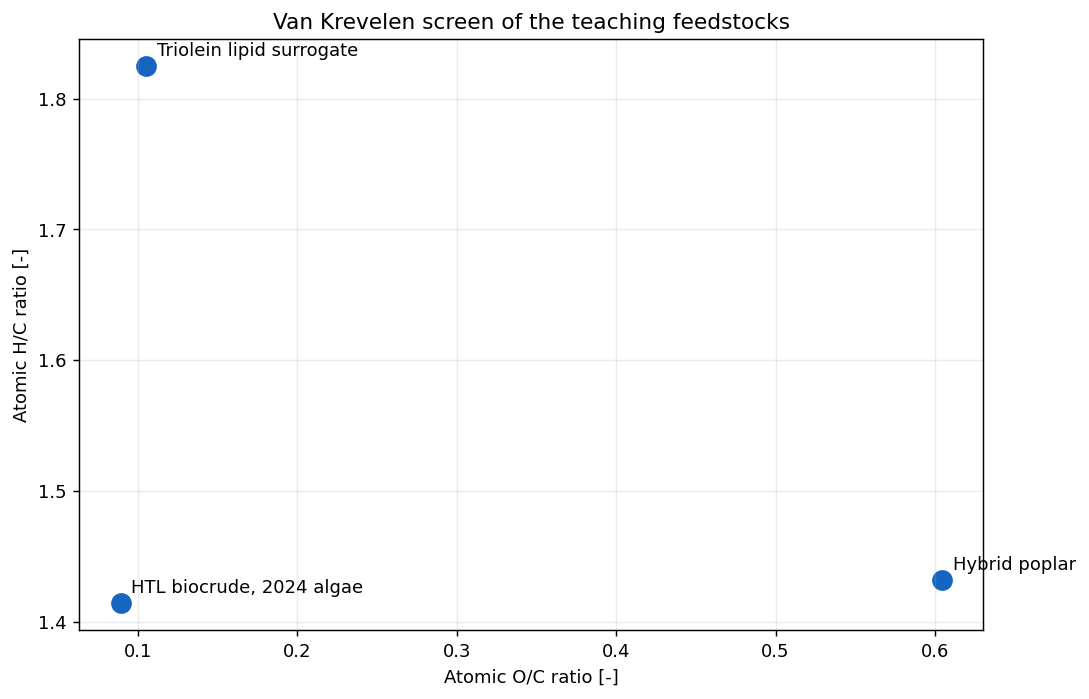

In [8]:
atomic = feedstocks.copy()
atomic["H_over_C"] = (
    atomic["H_wt_dry"] / 1.008
) / (atomic["C_wt_dry"] / 12.011)
atomic["O_over_C"] = (
    atomic["O_wt_dry"] / 15.999
) / (atomic["C_wt_dry"] / 12.011)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(atomic["O_over_C"], atomic["H_over_C"], s=110, color="#1565C0")
for _, row in atomic.iterrows():
    ax.annotate(
        row["Feedstock"],
        (row["O_over_C"], row["H_over_C"]),
        xytext=(6, 6),
        textcoords="offset points",
    )
ax.set_xlabel("Atomic O/C ratio [-]")
ax.set_ylabel("Atomic H/C ratio [-]")
ax.set_title("Van Krevelen screen of the teaching feedstocks")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Common pathway basis and first-pass assumptions

The route comparison below uses 1,000 kg dry feed and a 43 MJ/kg SAF lower
heating value. Reported liquid-fuel yields are converted from GGE/dry US ton
with 120.3 MJ/GGE and 907.185 kg/dry US ton. Because the PNNL pyrolysis and
HTL reports give total finished fuel rather than an aviation cut, 55 wt% is an
explicitly marked product-cut scenario. Utility rows are screening values and
must not be mistaken for harmonized literature data.


In [9]:
gge_mj = 120.3
dry_us_ton_kg = 907.18474
saf_lhv_reference = 43.0
pyro_total_fuel = (
    87.0 * gge_mj / saf_lhv_reference * 1000.0 / dry_us_ton_kg
)
htl_total_fuel = (
    133.0 * gge_mj / saf_lhv_reference * 1000.0 / dry_us_ton_kg
)
literature_to_saf_cut = 0.55

triolein_mw = 57.0 * 12.011 + 104.0 * 1.008 + 6.0 * 15.999
hefa_hydrogen = 15.0 * 2.016 / triolein_mw * 1000.0
hefa_c18_liquid = 3.0 * (18.0 * 12.011 + 38.0 * 1.008)
hefa_c18_liquid = hefa_c18_liquid / triolein_mw * 1000.0
hefa_saf_cut = 0.60

ethanol_per_t = (
    80.0 * 3.785411784 * 0.789 * 1000.0 / dry_us_ton_kg
)
atj_ethylene = ethanol_per_t * 28.054 / 46.069
atj_hydrogen = ethanol_per_t * 2.016 / (6.0 * 46.069)
atj_total_hydrocarbons = atj_ethylene + atj_hydrogen
atj_saf_cut = 0.80

route_data = pd.DataFrame(
    [
        [
            "HEFA",
            "Triolein lipid surrogate",
            hefa_c18_liquid * hefa_saf_cut,
            hefa_c18_liquid * (1.0 - hefa_saf_cut),
            hefa_hydrogen,
            55.0,
            1.0,
            37.2,
            0.7732,
            "DER-STOICH + SCN-PRODUCT-CUT",
            "SCN-UTILITIES",
        ],
        [
            "Gasification–FT",
            "Hybrid poplar",
            240.0,
            110.0,
            5.0,
            160.0,
            2.5,
            18.2,
            0.5060,
            "SCN-PRODUCT-CUT",
            "SCN-UTILITIES",
        ],
        [
            "ATJ",
            "Corn stover",
            atj_total_hydrocarbons * atj_saf_cut,
            atj_total_hydrocarbons * (1.0 - atj_saf_cut),
            atj_hydrogen,
            220.0,
            3.0,
            18.2,
            0.5060,
            "LIT-DOE-SAFFIRE-2023 + DER-STOICH + SCN-PRODUCT-CUT",
            "SCN-UTILITIES",
        ],
        [
            "Fast pyrolysis",
            "Hybrid poplar",
            pyro_total_fuel * literature_to_saf_cut,
            pyro_total_fuel * (1.0 - literature_to_saf_cut),
            22.4,
            231.0,
            0.0,
            18.2,
            0.5060,
            "LIT-PNNL-PYRO-2014 + SCN-PRODUCT-CUT",
            "LIT-PNNL-PYRO-2009 + DER-STOICH",
        ],
        [
            "HTL",
            "Wastewater biomass mixture",
            htl_total_fuel * literature_to_saf_cut,
            htl_total_fuel * (1.0 - literature_to_saf_cut),
            3.8,
            116.0,
            0.0,
            np.nan,
            np.nan,
            "LIT-PNNL-HTL-2024 + SCN-PRODUCT-CUT",
            "LIT-PNNL-HTL-2024 + DER-STOICH",
        ],
        [
            "CO₂ + H₂ hybrid",
            "600 kg captured biogenic CO₂",
            133.6,
            57.3,
            81.8,
            350.0,
            0.0,
            0.0,
            np.nan,
            "DER-STOICH + SCN-PRODUCT-CUT",
            "DER-STOICH",
        ],
    ],
    columns=[
        "Route",
        "Feedstock",
        "SAF_kg",
        "Cofuel_kg",
        "H2_kg",
        "Electricity_kWh",
        "Imported_heat_GJ",
        "Feed_LHV_MJ_kg",
        "Feed_C_mass_fraction",
        "yield_source_id",
        "utility_source_id",
    ],
)
route_data["SAF_yield_kg_per_t_dry"] = route_data["SAF_kg"]
route_data["SAF_carbon_efficiency"] = (
    route_data["SAF_kg"] * 0.85
) / (1000.0 * route_data["Feed_C_mass_fraction"])
route_data.loc[
    route_data["Route"] == "Fast pyrolysis", "SAF_carbon_efficiency"
] = 0.47 * literature_to_saf_cut
route_data.loc[
    route_data["Route"] == "HTL", "SAF_carbon_efficiency"
] = 0.44 * literature_to_saf_cut
hybrid_carbon_feed = 600.0 * 12.011 / 44.009
route_data.loc[
    route_data["Route"] == "CO₂ + H₂ hybrid", "SAF_carbon_efficiency"
] = 133.6 * 0.85 / hybrid_carbon_feed
display(route_data.round(3))


          Route                    Feedstock  SAF_kg  Cofuel_kg  H2_kg  Electricity_kWh  Imported_heat_GJ  Feed_LHV_MJ_kg  Feed_C_mass_fraction                                     yield_source_id               utility_source_id  SAF_yield_kg_per_t_dry  SAF_carbon_efficiency
           HEFA     Triolein lipid surrogate 517.366    344.911 34.152             55.0               1.0            37.2                 0.773                        DER-STOICH + SCN-PRODUCT-CUT                   SCN-UTILITIES                 517.366                  0.569
Gasification–FT                Hybrid poplar 240.000    110.000  5.000            160.0               2.5            18.2                 0.506                                     SCN-PRODUCT-CUT                   SCN-UTILITIES                 240.000                  0.403
            ATJ                  Corn stover 129.847     32.462  1.921            220.0               3.0            18.2                 0.506 LIT-DOE-SAFFIRE-2023 + DER-STOI

In [10]:
input_ledger = pd.DataFrame(
    [
        ["BASIS-DRY-FEED", "Calculation basis", 1000.0, "kg dry feed", "SCN-UTILITIES"],
        ["ENERGY-SAF-LHV", "SAF LHV", 43.0, "MJ/kg", "LIT-ICAO-2025"],
        ["ENERGY-H2-LHV", "Hydrogen LHV", 120.0, "MJ/kg", "DATA-DOE-H2"],
        ["PRODUCT-CARBON", "SAF surrogate carbon", 85.0, "wt%", "SCN-PRODUCT-CUT"],
        ["ENERGY-GGE", "Gasoline-gallon equivalent", 120.3, "MJ/GGE", "DER-STOICH"],
        ["MASS-SHORT-TON", "Dry US ton", 907.18474, "kg", "DER-STOICH"],
        ["HEFA-H2", "Triolein HDO hydrogen", hefa_hydrogen, "kg/t feed", "DER-STOICH"],
        ["HEFA-SAF-CUT", "HEFA liquid assigned to SAF", 60.0, "wt%", "SCN-PRODUCT-CUT"],
        [
            "ATJ-ETHANOL",
            "Cellulosic ethanol",
            ethanol_per_t,
            "kg/t dry feed",
            "LIT-DOE-SAFFIRE-2023 + DER-STOICH",
        ],
        ["ATJ-SAF-CUT", "ATJ hydrocarbons assigned to SAF", 80.0, "wt%", "SCN-PRODUCT-CUT"],
        [
            "PYRO-FUEL",
            "Finished fuel",
            pyro_total_fuel,
            "kg/t dry feed",
            "LIT-PNNL-PYRO-2014 + DER-STOICH",
        ],
        [
            "HTL-FUEL",
            "Finished fuel, scenario 3",
            htl_total_fuel,
            "kg/t AFDW",
            "LIT-PNNL-HTL-2024 + DER-STOICH",
        ],
        ["PYRO-HTL-SAF-CUT", "Finished fuel assigned to SAF", 55.0, "wt%", "SCN-PRODUCT-CUT"],
        ["FT-ASF-ALPHA", "ASF chain-growth probability", 0.85, "-", "SCN-PRODUCT-CUT"],
        ["COMP-ETA", "Compressor isentropic efficiency", 0.78, "-", "SCN-NEQSIM-SURROGATE"],
        ["COMP-FLOW", "Syngas compressor flow", 1000.0, "kg/h", "SCN-NEQSIM-SURROGATE"],
        ["COMP-P-IN", "Syngas compressor inlet", 2.0, "bara", "SCN-NEQSIM-SURROGATE"],
        ["COMP-P-OUT", "Syngas compressor outlet", 25.0, "bara", "SCN-NEQSIM-SURROGATE"],
        ["COMP-STAGES", "Compared compressor stages", 3.0, "stages", "SCN-NEQSIM-SURROGATE"],
        ["FLASH-HEFA", "HEFA separator T/P", 40.0, "°C at 35 bara", "SCN-NEQSIM-SURROGATE"],
        ["FLASH-ATJ", "ATJ separator T/P", 30.0, "°C at 20 bara", "SCN-NEQSIM-SURROGATE"],
        ["FLASH-SYNGAS", "Wet syngas cooler T/P", 35.0, "°C at 25 bara", "SCN-NEQSIM-SURROGATE"],
        ["LOG-Q", "Recoverable areal density", 75.0, "t/(km² y)", "SCN-LOGISTICS"],
        ["LOG-SAF", "Annual SAF target", 100000.0, "t/y", "SCN-LOGISTICS"],
        ["TEA-DISCOUNT", "Real discount rate", 8.0, "%", "SCN-TEA"],
        ["TEA-LIFE", "Project life", 20.0, "year", "SCN-TEA"],
        ["TEA-FOM", "Fixed O&M fraction of CAPEX", 4.0, "%/year", "SCN-TEA"],
        ["MC-SAMPLES", "Monte Carlo sample count", 5000.0, "draws", "SCN-TEA"],
        ["MC-YIELD-CV", "Yield normal standard deviation", 10.0, "% of mean", "SCN-TEA"],
        ["MC-COST-SIGMA", "CAPEX/feed lognormal sigma", 0.20, "log-space", "SCN-TEA"],
        ["MC-H2-SD", "Hydrogen-price standard deviation", 1.0, "EUR/kg", "SCN-TEA"],
    ],
    columns=["input_id", "parameter", "value", "unit", "source_id"],
)
display(input_ledger.round(4))


        input_id                         parameter       value          unit                         source_id
  BASIS-DRY-FEED                 Calculation basis   1000.0000   kg dry feed                     SCN-UTILITIES
  ENERGY-SAF-LHV                           SAF LHV     43.0000         MJ/kg                     LIT-ICAO-2025
   ENERGY-H2-LHV                      Hydrogen LHV    120.0000         MJ/kg                       DATA-DOE-H2
  PRODUCT-CARBON              SAF surrogate carbon     85.0000           wt%                   SCN-PRODUCT-CUT
      ENERGY-GGE        Gasoline-gallon equivalent    120.3000        MJ/GGE                        DER-STOICH
  MASS-SHORT-TON                        Dry US ton    907.1847            kg                        DER-STOICH
         HEFA-H2             Triolein HDO hydrogen     34.1520     kg/t feed                        DER-STOICH
    HEFA-SAF-CUT       HEFA liquid assigned to SAF     60.0000           wt%                   SCN-PRODUCT-CUT
 

## 7. Concept A — HEFA from fats, oils, and greases

HEFA pretreatment removes water, metals, phosphorus, nitrogen, sulfur, and
other catalyst poisons. Hydrotreating saturates double bonds and removes
oxygen through hydrodeoxygenation and decarboxylation/decarbonylation.
Isomerization and hydrocracking improve cold-flow properties and shift product
into the jet range; fractionation then separates LPG/naphtha, SAF, and diesel.

Simplified reaction families are

$$RCOOR'+H_2\rightarrow RH+R'OH+H_2O$$

$$RCOOH+H_2\rightarrow RH+CO_2$$

A closed stoichiometric teaching case treats the lipid as triolein and chooses
complete hydrodeoxygenation:

$$C_{57}H_{104}O_6+15H_2\rightarrow 3C_{18}H_{38}+C_3H_8+6H_2O$$

More hydrodeoxygenation preserves feed carbon but consumes more hydrogen;
decarboxylation loses carbon as $CO_2$. Catalyst choice, feed impurities,
isomerization severity, and the desired SAF/diesel split dominate the design.


In [11]:
hefa_input = {"triolein_surrogate": 1000.0, "hydrogen": hefa_hydrogen}
hefa_propane = (3.0 * 12.011 + 8.0 * 1.008) / triolein_mw * 1000.0
hefa_water = 6.0 * (2.0 * 1.008 + 15.999) / triolein_mw * 1000.0
hefa_output = {
    "C18_liquid_before_product_cut": hefa_c18_liquid,
    "propane": hefa_propane,
    "water": hefa_water,
}
hefa_balance = pd.DataFrame(
    {
        "Input_kg": pd.Series(hefa_input),
        "Output_kg": pd.Series(hefa_output),
    }
).fillna(0.0)
hefa_mass_error = sum(hefa_input.values()) - sum(hefa_output.values())
print(f"HEFA total mass-balance residual: {hefa_mass_error:.3f} kg")
print(f"Stoichiometric H₂: {hefa_input['hydrogen']:.1f} kg/t lipid feed")
print(f"C18 liquid before hydrocracking: {hefa_c18_liquid:.1f} kg/t feed")
print(f"SAF at the 60 wt% scenario cut: {hefa_c18_liquid * hefa_saf_cut:.1f} kg/t")
display(hefa_balance.rename_axis("Stream").reset_index())


HEFA total mass-balance residual: 0.000 kg
Stoichiometric H₂: 34.2 kg/t lipid feed
C18 liquid before hydrocracking: 862.3 kg/t feed
SAF at the 60 wt% scenario cut: 517.4 kg/t
                       Stream   Input_kg  Output_kg
C18_liquid_before_product_cut    0.00000 862.277275
                     hydrogen   34.15201   0.000000
                      propane    0.00000  49.801627
           triolein_surrogate 1000.00000   0.000000
                        water    0.00000 122.073108


## 8. NeqSim calculation backend

The following helper runs the NeqSim Java core from Python. In Colab the JAR
comes from the pinned `neqsim` wheel; in the validation environment an explicit
compatible JAR may be supplied. This keeps the numerical engine identical while
avoiding hidden notebook state.

The SRK equation of state with the classic mixing rule is used for transparent
screening. Water-rich systems and oxygenates can require CPA, electrolyte, or
validated binary interaction parameters in detailed work. Heavy SAF molecules
are represented by conventional hydrocarbon surrogates (`n-heptane`, `nC10`,
`nC12`, `nC16`) rather than a full refinery assay.


In [12]:
JAVA_SOURCE = r"""
import neqsim.process.equipment.compressor.Compressor;
import neqsim.process.equipment.heatexchanger.Cooler;
import neqsim.process.equipment.stream.Stream;
import neqsim.standards.oilquality.Standard_ASTM_D86;
import neqsim.standards.oilquality.Standard_ASTM_D4052;
import neqsim.standards.oilquality.Standard_ASTM_D445;
import neqsim.standards.oilquality.Standard_ASTM_D1322;
import neqsim.thermo.system.SystemInterface;
import neqsim.thermo.system.SystemSrkEos;
import neqsim.thermodynamicoperations.ThermodynamicOperations;

public class NeqsimSafRunner {
  private static SystemInterface makeFluid(
      double temperatureC, double pressureBar, String[] args, int startIndex) {
    SystemInterface fluid = new SystemSrkEos(temperatureC + 273.15, pressureBar);
    for (int index = startIndex; index < args.length; index++) {
      String[] pair = args[index].split(":", 2);
      fluid.addComponent(pair[0], Double.parseDouble(pair[1]));
    }
    fluid.setMixingRule("classic");
    fluid.setMultiPhaseCheck(true);
    return fluid;
  }

  private static void flash(String[] args) {
    double temperatureC = Double.parseDouble(args[1]);
    double pressureBar = Double.parseDouble(args[2]);
    SystemInterface fluid = makeFluid(temperatureC, pressureBar, args, 3);
    ThermodynamicOperations operations = new ThermodynamicOperations(fluid);
    operations.TPflash();
    fluid.initProperties();
    System.out.println("FLASH|" + fluid.getNumberOfPhases());
    for (int index = 0; index < fluid.getNumberOfPhases(); index++) {
      System.out.println(
          "PHASE|" + index
              + "|" + fluid.getPhase(index).getPhaseTypeName()
              + "|" + fluid.getPhase(index).getBeta()
              + "|" + fluid.getPhase(index).getDensity("kg/m3")
              + "|" + fluid.getPhase(index).getComponent("water").getx());
    }
  }

  private static void compress(String[] args) {
    double temperatureC = Double.parseDouble(args[1]);
    double inletPressure = Double.parseDouble(args[2]);
    double outletPressure = Double.parseDouble(args[3]);
    double flowKgHr = Double.parseDouble(args[4]);
    double efficiency = Double.parseDouble(args[5]);
    int stages = Integer.parseInt(args[6]);
    SystemInterface fluid = makeFluid(temperatureC, inletPressure, args, 7);
    ThermodynamicOperations operations = new ThermodynamicOperations(fluid);
    operations.TPflash();
    Stream current = new Stream("clean syngas", fluid);
    current.setFlowRate(flowKgHr, "kg/hr");
    current.run();
    double ratio = Math.pow(outletPressure / inletPressure, 1.0 / stages);
    double totalPower = 0.0;
    for (int stage = 1; stage <= stages; stage++) {
      double stagePressure = inletPressure * Math.pow(ratio, stage);
      Compressor compressor = new Compressor("compressor " + stage, current);
      compressor.setOutletPressure(stagePressure, "bara");
      compressor.setIsentropicEfficiency(efficiency);
      compressor.run();
      Cooler cooler = new Cooler("intercooler " + stage, compressor.getOutletStream());
      cooler.setOutTemperature(temperatureC + 273.15);
      cooler.run();
      totalPower += compressor.getPower("kW");
      System.out.println(
          "STAGE|" + stage
              + "|" + stagePressure
              + "|" + compressor.getOutletStream().getTemperature("C")
              + "|" + compressor.getPower("kW")
              + "|" + cooler.getDuty("kW"));
      current = new Stream("cooled syngas " + stage, cooler.getOutletStream());
      current.run();
    }
    System.out.println("TOTAL_POWER|" + totalPower);
  }

  private static void quality(String[] args) {
    SystemInterface oil = new SystemSrkEos(273.15 + 15.0, 1.01325);
    for (int index = 1; index < args.length; index++) {
      String[] fields = args[index].split(":", 4);
      oil.addTBPfraction(
          fields[0],
          Double.parseDouble(fields[1]),
          Double.parseDouble(fields[2]),
          Double.parseDouble(fields[3]));
    }
    oil.setMixingRule(2);
    oil.init(0);

    Standard_ASTM_D4052 density = new Standard_ASTM_D4052(oil);
    density.calculate();
    Standard_ASTM_D445 viscosity = new Standard_ASTM_D445(oil);
    viscosity.calculate();
    Standard_ASTM_D86 distillation = new Standard_ASTM_D86(oil);
    distillation.calculate();
    Standard_ASTM_D1322 smoke = new Standard_ASTM_D1322(oil);
    smoke.calculate();

    System.out.println(
        "QUALITY|"
            + density.getValue("density") + "|"
            + density.getValue("API") + "|"
            + viscosity.getValue("KV40") + "|"
            + viscosity.getValue("KV100") + "|"
            + distillation.getValue("IBP", "C") + "|"
            + distillation.getValue("T10", "C") + "|"
            + distillation.getValue("T50", "C") + "|"
            + distillation.getValue("T90", "C") + "|"
            + distillation.getValue("FBP", "C") + "|"
            + distillation.getValue("WatsonK") + "|"
            + smoke.getValue("smokePoint", "mm"));
    for (double[] point : distillation.getDistillationCurve()) {
      System.out.println("CURVE|" + point[0] + "|" + point[1]);
    }
  }

  public static void main(String[] args) {
    if (args[0].equals("flash")) {
      flash(args);
    } else if (args[0].equals("compress")) {
      compress(args);
    } else if (args[0].equals("quality")) {
      quality(args);
    } else {
      throw new IllegalArgumentException("Unknown command: " + args[0]);
    }
  }
}
"""

java_file = Path(tempfile.gettempdir()) / "NeqsimSafRunner.java"
java_file.write_text(JAVA_SOURCE, encoding="utf-8")

def run_java_neqsim(arguments):
    command = [
        "java",
        "--class-path",
        str(neqsim_jar),
        str(java_file),
        *[str(argument) for argument in arguments],
    ]
    result = subprocess.run(command, check=True, capture_output=True, text=True)
    return result.stdout.splitlines()

def neqsim_flash(temperature_c, pressure_bar, composition):
    component_arguments = [
        f"{name}:{amount}" for name, amount in composition.items()
    ]
    lines = run_java_neqsim(
        ["flash", temperature_c, pressure_bar, *component_arguments]
    )
    records = []
    for line in lines:
        fields = line.split("|")
        if fields[0] == "PHASE":
            records.append(
                {
                    "phase_index": int(fields[1]),
                    "phase": fields[2],
                    "molar_phase_fraction": float(fields[3]),
                    "density_kg_m3": float(fields[4]),
                    "water_mole_fraction": float(fields[5]),
                }
            )
    return pd.DataFrame(records)

def neqsim_compression(
    temperature_c,
    inlet_pressure_bar,
    outlet_pressure_bar,
    flow_kg_hr,
    efficiency,
    stages,
    composition,
):
    component_arguments = [
        f"{name}:{amount}" for name, amount in composition.items()
    ]
    lines = run_java_neqsim(
        [
            "compress",
            temperature_c,
            inlet_pressure_bar,
            outlet_pressure_bar,
            flow_kg_hr,
            efficiency,
            stages,
            *component_arguments,
        ]
    )
    records = []
    total_power = np.nan
    for line in lines:
        fields = line.split("|")
        if fields[0] == "STAGE":
            records.append(
                {
                    "stage": int(fields[1]),
                    "outlet_pressure_bara": float(fields[2]),
                    "compressor_outlet_C": float(fields[3]),
                    "power_kW": float(fields[4]),
                    "cooler_duty_kW": float(fields[5]),
                }
            )
        if fields[0] == "TOTAL_POWER":
            total_power = float(fields[1])
    return pd.DataFrame(records), total_power

def neqsim_oil_quality(tbp_fractions):
    fraction_arguments = [
        f"{name}:{amount}:{molar_mass}:{density}"
        for name, amount, molar_mass, density in tbp_fractions
    ]
    lines = run_java_neqsim(["quality", *fraction_arguments])
    quality = {}
    curve_records = []
    quality_keys = [
        "density_15C_kg_m3",
        "API_gravity",
        "KV40_cSt",
        "KV100_cSt",
        "IBP_C",
        "T10_C",
        "T50_C",
        "T90_C",
        "FBP_C",
        "Watson_K",
        "smoke_point_mm_estimate",
    ]
    for line in lines:
        fields = line.split("|")
        if fields[0] == "QUALITY":
            quality = {
                key: (
                    np.nan
                    if key.startswith("KV") and not np.isfinite(float(value))
                    else float(value)
                )
                for key, value in zip(quality_keys, fields[1:])
            }
        if fields[0] == "CURVE":
            curve_records.append(
                {
                    "recovered_vol_pct": float(fields[1]),
                    "temperature_C": float(fields[2]),
                }
            )
    return quality, pd.DataFrame(curve_records)

print(f"NeqSim Java runner prepared at {java_file}")


NeqSim Java runner prepared at /tmp/NeqsimSafRunner.java


### HEFA reactor-effluent cooling and separation

The surrogate stream contains excess hydrogen and light gas, water, $CO_2$,
and light/heavy hydrocarbons. A 40 °C, 35 bara TP flash should form a gas,
hydrocarbon liquid, and water-rich phase. This is precisely the type of
equilibrium and property calculation for which NeqSim is useful. All component
amounts in this normalized stream are `SCN-NEQSIM-SURROGATE`; they represent
product families, not a measured HEFA assay.


In [13]:
hefa_surrogate = {
    "hydrogen": 20.0,
    "propane": 8.0,
    "CO2": 5.0,
    "water": 15.0,
    "n-heptane": 5.0,
    "nC10": 35.0,
    "nC16": 12.0,
}
hefa_flash = neqsim_flash(40.0, 35.0, hefa_surrogate)
print("NeqSim SRK flash: HEFA upgrading effluent at 40 °C and 35 bara")
display(hefa_flash.round(5))


NeqSim SRK flash: HEFA upgrading effluent at 40 °C and 35 bara
 phase_index   phase  molar_phase_fraction  density_kg_m3  water_mole_fraction
           0     gas               0.21117       11.04947              0.00184
           1     oil               0.64996      739.36580              0.01655
           2 aqueous               0.13886      988.28134              0.99994


The expected three-phase split is obtained. The gas phase is the location for
hydrogen recovery/recycle; the oil phase contains the SAF-range surrogates;
and the aqueous phase removes reaction water. A detailed design would replace
the surrogate assay, regress interaction parameters, include dissolved gases,
and model amine/water treatment and hydrogen purity constraints.


## 9. Concept B — biomass gasification and Fischer–Tropsch synthesis

A typical chain is drying and size reduction; oxygen/steam gasification;
particulate, alkali, chlorine, sulfur, ammonia, and tar removal; water-gas
shift or hydrogen addition; compression; FT synthesis; hydrocracking,
isomerization, and fractionation.

The idealized gasification and shift chemistry includes

$$C+H_2O\rightarrow CO+H_2$$

$$CO+H_2O\rightleftharpoons CO_2+H_2$$

and the paraffin-forming FT family

$$nCO+(2n+1)H_2\rightarrow C_nH_{2n+2}+nH_2O$$

Real performance depends on gasifier type, oxygen demand, steam ratio,
temperature, pressure, carbon conversion, tar/methane formation, cleanup
losses, catalyst choice, recycle, and heat integration. The two syngas assays
below are normalized `SCN-NEQSIM-SURROGATE` inputs chosen to expose the shift,
condensation, and compression calculations; they are not plant measurements.


In [14]:
wood = feedstocks.loc[feedstocks["Feedstock"] == "Hybrid poplar"].iloc[0]
carbon_kmol = wood["C_wt_dry"] / 12.011
hydrogen_atom_kmol = wood["H_wt_dry"] / 1.008
oxygen_atom_kmol = wood["O_wt_dry"] / 15.999
empirical_h = hydrogen_atom_kmol / carbon_kmol
empirical_o = oxygen_atom_kmol / carbon_kmol

raw_syngas = {"H2": 42.0, "CO": 34.0, "CO2": 10.0, "water": 8.0,
              "methane": 4.0, "nitrogen": 2.0}
raw_ratio = raw_syngas["H2"] / raw_syngas["CO"]
shift_needed = (2.0 * raw_syngas["CO"] - raw_syngas["H2"]) / 3.0
maximum_shift = raw_syngas["water"]
maximum_ratio = (
    raw_syngas["H2"] + maximum_shift
) / (raw_syngas["CO"] - maximum_shift)

print(f"Forestry-residue empirical formula: CH{empirical_h:.2f}O{empirical_o:.2f}")
print(f"Specified raw H₂/CO ratio: {raw_ratio:.3f} mol/mol")
print(f"Shift extent required for H₂/CO = 2: {shift_needed:.3f} mol per 100 mol")
print(f"Maximum ratio with only specified steam: {maximum_ratio:.3f} mol/mol")


Forestry-residue empirical formula: CH1.43O0.60
Specified raw H₂/CO ratio: 1.235 mol/mol
Shift extent required for H₂/CO = 2: 8.667 mol per 100 mol
Maximum ratio with only specified steam: 1.923 mol/mol


The specified wet syngas does not contain quite enough steam to reach an
$H_2/CO$ ratio of 2 by shift alone. The designer can add steam, import hydrogen,
change gasification severity, use an iron FT catalyst with water-gas-shift
activity, or accept a different loop ratio. Each choice changes carbon yield,
heat recovery, compression, and lifecycle intensity.


In [15]:
syngas_flash = neqsim_flash(35.0, 25.0, raw_syngas)
print("NeqSim SRK flash: wet syngas after cooling at 35 °C and 25 bara")
display(syngas_flash.round(6))

gas_row = syngas_flash.loc[syngas_flash["phase"] == "gas"].iloc[0]
aqueous_row = syngas_flash.loc[syngas_flash["phase"] == "aqueous"].iloc[0]
print(f"Gas water mole fraction: {gas_row['water_mole_fraction']:.5f}")
print(f"Aqueous molar phase fraction: {aqueous_row['molar_phase_fraction']:.4f}")


NeqSim SRK flash: wet syngas after cooling at 35 °C and 25 bara
 phase_index   phase  molar_phase_fraction  density_kg_m3  water_mole_fraction
           0     gas              0.921809      16.911376             0.001965
           1 aqueous              0.078191     992.844653             0.999958
Gas water mole fraction: 0.00197
Aqueous molar phase fraction: 0.0782


Cooling removes most of the water before the FT loop. The remaining water
content is an equilibrium result for the stated surrogate, equation of state,
temperature, and pressure—not a catalyst-specification guarantee. Adsorption,
further cooling, or other polishing may be needed.


In [16]:
clean_syngas = {
    "hydrogen": 45.0,
    "CO": 36.0,
    "CO2": 10.0,
    "water": 0.2,
    "methane": 6.0,
    "nitrogen": 2.8,
}
one_stage, one_stage_power = neqsim_compression(
    35.0, 2.0, 25.0, 1000.0, 0.78, 1, clean_syngas
)
three_stage, three_stage_power = neqsim_compression(
    35.0, 2.0, 25.0, 1000.0, 0.78, 3, clean_syngas
)
compression_saving = 100.0 * (one_stage_power - three_stage_power) / one_stage_power

print("Three-stage NeqSim compression train with 35 °C intercooling")
display(three_stage.round(2))
print(f"One-stage power: {one_stage_power:.1f} kW per 1,000 kg/h syngas")
print(f"Three-stage power: {three_stage_power:.1f} kW per 1,000 kg/h syngas")
print(f"Power reduction from staging: {compression_saving:.1f}%")


Three-stage NeqSim compression train with 35 °C intercooling
 stage  outlet_pressure_bara  compressor_outlet_C  power_kW  cooler_duty_kW
     1                  4.64               136.14     50.32          -50.50
     2                 10.77               136.21     50.38          -50.80
     3                 25.00               136.37     50.52          -51.49
One-stage power: 192.5 kW per 1,000 kg/h syngas
Three-stage power: 151.2 kW per 1,000 kg/h syngas
Power reduction from staging: 21.4%


### Anderson–Schulz–Flory product distribution

For a simple chain-growth probability $\alpha$, the ideal molar probability
of carbon number $n$ is

$$x_n=(1-\alpha)\alpha^{n-1}$$

Mass selectivity is proportional to $nx_n$. This explains why conventional
FT cannot direct all product into the jet range. Hydrocracking and
isomerization can increase recovered SAF, but add hydrogen, equipment, yield
loss, and heat duty. IEA Bioenergy notes a straight-run jet fraction near 40%
as an upper-order result for conventional ASF behavior.


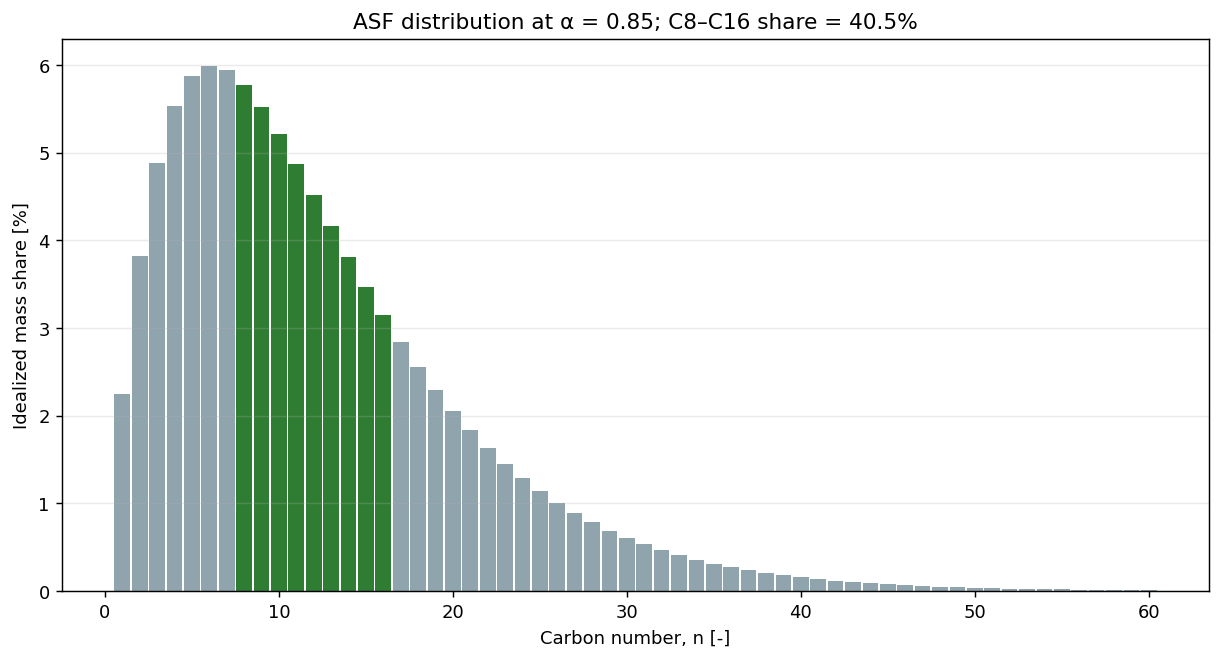

In [17]:
carbon_numbers = np.arange(1, 61)
alpha = 0.85
molar_probability = (1.0 - alpha) * alpha ** (carbon_numbers - 1)
mass_probability = carbon_numbers * molar_probability
mass_probability = mass_probability / mass_probability.sum()
jet_mask = (carbon_numbers >= 8) & (carbon_numbers <= 16)
straight_run_jet = mass_probability[jet_mask].sum()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
bar_colors = np.where(jet_mask, "#2E7D32", "#90A4AE")
ax.bar(carbon_numbers, 100.0 * mass_probability, color=bar_colors, width=0.9)
ax.set_xlabel("Carbon number, n [-]")
ax.set_ylabel("Idealized mass share [%]")
ax.set_title(f"ASF distribution at α = {alpha:.2f}; C8–C16 share = {100*straight_run_jet:.1f}%")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 10. Concept C — alcohol-to-jet (ATJ)

ATJ separates biomass-to-alcohol production from alcohol upgrading. Ethanol
may come from sugar/starch fermentation, cellulosic hydrolysis and fermentation,
or syngas fermentation. The upgrading train generally includes dehydration to
olefins, oligomerization, hydrogenation, isomerization, and fractionation:

$$C_2H_5OH\rightarrow C_2H_4+H_2O$$

$$mC_2H_4\rightarrow C_{2m}H_{4m}$$

Integration matters because alcohol concentration and purification consume
substantial heat. Feedstock carbon can also leave with fermentation $CO_2$,
lignin/solids, wastewater organics, and light upgrading products. The final
NeqSim assay is again a normalized `SCN-NEQSIM-SURROGATE`, not an experimental
ATJ product assay.


In [18]:
ethanol_yield = ethanol_per_t
total_hydrocarbons = atj_total_hydrocarbons
atj_saf = total_hydrocarbons * atj_saf_cut
atj_cofuel = total_hydrocarbons - atj_saf
atj_reaction_water = ethanol_yield * 18.015 / 46.069

atj_balance = pd.DataFrame(
    [
        ["SAF", atj_saf],
        ["Other hydrocarbons", atj_cofuel],
        ["Dehydration water", atj_reaction_water],
    ],
    columns=["Output", "kg_per_t_dry_biomass"],
)
atj_mass_residual = (
    ethanol_yield + atj_hydrogen - atj_balance.iloc[:, 1].sum()
)
print("Source basis: 80 US gal ethanol/dry US ton corn stover")
print(f"Converted ethanol intermediate: {ethanol_yield:.1f} kg/t dry biomass")
print(f"ATJ SAF yield: {atj_saf:.1f} kg/t dry biomass")
print(f"ATJ upgrading mass-balance residual: {atj_mass_residual:.3f} kg")
display(atj_balance.round(1))


Source basis: 80 US gal ethanol/dry US ton corn stover
Converted ethanol intermediate: 263.4 kg/t dry biomass
ATJ SAF yield: 129.8 kg/t dry biomass
ATJ upgrading mass-balance residual: 0.000 kg
            Output  kg_per_t_dry_biomass
               SAF                 129.8
Other hydrocarbons                  32.5
 Dehydration water                 103.0


In [19]:
atj_surrogate = {
    "hydrogen": 5.0,
    "propane": 4.0,
    "CO2": 1.0,
    "water": 35.0,
    "ethanol": 5.0,
    "n-heptane": 8.0,
    "nC10": 32.0,
    "nC12": 10.0,
}
atj_flash = neqsim_flash(30.0, 20.0, atj_surrogate)
print("NeqSim SRK flash: cooled ATJ upgrading effluent at 30 °C and 20 bara")
display(atj_flash.round(5))


NeqSim SRK flash: cooled ATJ upgrading effluent at 30 °C and 20 bara
 phase_index   phase  molar_phase_fraction  density_kg_m3  water_mole_fraction
           0     gas               0.04361        4.58733              0.00169
           1     oil               0.61371      733.39799              0.01210
           2 aqueous               0.34268      997.23311              0.99947


The ATJ surrogate also gives gas, hydrocarbon-liquid, and aqueous phases.
Residual ethanol partitions between liquid phases and affects wastewater and
recycle design. For rigorous ethanol–water behavior, use a validated
associating/activity-coefficient treatment and experimental data rather than
accepting the SRK teaching result as final.


## 11. Concept D — fast pyrolysis and bio-oil upgrading

Fast pyrolysis heats small, relatively dry biomass particles without oxygen,
normally near 500 °C with vapor residence below about two seconds. PNNL-18284
models hybrid poplar dried to 7 wt% water, a 520 °C circulating fluidized bed,
and the four primary products shown below. The liquid is **pyrolysis bio-oil**:
a reactive mixture of water, acids, aldehydes, ketones, phenolics, sugars, and
oligomers. It is not the same material as HTL biocrude.

Rapid quenching maximizes liquid yield. Char and part of the non-condensable
gas can provide process heat. Alkali and ash promote cracking; slow vapor
removal promotes secondary reactions. Raw bio-oil is acidic, oxygen-rich, and
unstable, so staged stabilization and hydrodeoxygenation are required before
hydrocracking, isomerization, and an aviation boiling-range cut.

PNNL-24176 uses three upgrading beds at 140 °C/1,200 psig,
252 °C/2,000 psig, and about 400 °C/2,000 psig. It reports 87 GGE total
finished fuel per dry US ton and 47% carbon-to-fuel efficiency for its 2014
state-of-technology case. Those fuels were gasoline/diesel blendstocks; the
55 wt% SAF cut below is therefore an editable scenario, not a reported SAF yield.


In [20]:
pyrolysis_products = pd.DataFrame(
    [
        ["Pyrolysis bio-oil", 65.0, "Oxygenated liquid; about 21 wt% water"],
        ["Separate reaction water", 10.0, "Aqueous condensate"],
        ["Char and ash", 13.0, "Solid carbon/minerals; potential process heat"],
        ["Non-condensable gas", 12.0, "CO, CO₂, CH₄ and light species"],
    ],
    columns=["Primary product", "kg_per_100_kg_dry_feed", "Interpretation"],
)
pyro_mass_residual = 100.0 - pyrolysis_products["kg_per_100_kg_dry_feed"].sum()
pyro_saf = pyro_total_fuel * literature_to_saf_cut
pyro_cofuel = pyro_total_fuel - pyro_saf

wet_bio_oil = 650.0
bio_oil_water_fraction = 0.21
dry_bio_oil_oxygen_fraction = 0.36
stable_oil_yield_from_wet_oil = 0.44
stable_oil_oxygen_fraction = 0.02
bio_oil_oxygen = (
    wet_bio_oil * (1.0 - bio_oil_water_fraction)
    * dry_bio_oil_oxygen_fraction
)
stable_oil_oxygen = (
    wet_bio_oil * stable_oil_yield_from_wet_oil
    * stable_oil_oxygen_fraction
)
minimum_h2_for_water = (bio_oil_oxygen - stable_oil_oxygen) / 8.0

display(pyrolysis_products)
print(f"Primary-product closure residual: {pyro_mass_residual:.2f} kg/100 kg")
print(f"Total finished fuel from 87 GGE/dry US ton: {pyro_total_fuel:.1f} kg/t")
print(f"SAF at the 55 wt% scenario cut: {pyro_saf:.1f} kg/t dry feed")
print(f"Other finished fuel: {pyro_cofuel:.1f} kg/t dry feed")
print(f"Minimum H₂ if removed oxygen forms water: {minimum_h2_for_water:.1f} kg/t")


        Primary product  kg_per_100_kg_dry_feed                                Interpretation
      Pyrolysis bio-oil                    65.0         Oxygenated liquid; about 21 wt% water
Separate reaction water                    10.0                            Aqueous condensate
           Char and ash                    13.0 Solid carbon/minerals; potential process heat
    Non-condensable gas                    12.0                CO, CO₂, CH₄ and light species
Primary-product closure residual: 0.00 kg/100 kg
Total finished fuel from 87 GGE/dry US ton: 268.3 kg/t
SAF at the 55 wt% scenario cut: 147.6 kg/t dry feed
Other finished fuel: 120.7 kg/t dry feed
Minimum H₂ if removed oxygen forms water: 22.4 kg/t


In [21]:
pyro_upgrade_surrogate = {
    "hydrogen": 12.0,
    "methane": 5.0,
    "CO2": 8.0,
    "water": 35.0,
    "n-heptane": 5.0,
    "nC10": 20.0,
    "nC12": 15.0,
    "nC16": 5.0,
}
pyro_upgrade_flash = neqsim_flash(40.0, 35.0, pyro_upgrade_surrogate)
print("NeqSim SRK flash: normalized fast-pyrolysis upgrading surrogate")
display(pyro_upgrade_flash.round(5))


NeqSim SRK flash: normalized fast-pyrolysis upgrading surrogate
 phase_index   phase  molar_phase_fraction  density_kg_m3  water_mole_fraction
           0     gas               0.16700       17.22725              0.00192
           1     oil               0.50921      746.52207              0.01817
           2 aqueous               0.32379      988.30535              0.99989


The oxygen-removal calculation is a theoretical floor. Actual hydrogen use is
higher when reactive species are saturated, nitrogen and sulfur are removed,
gas is formed, and recycle/purge losses are included. The NeqSim stream is a
`SCN-NEQSIM-SURROGATE`: it tests three-phase cooling and separation, not raw
bio-oil thermodynamics. Raw bio-oil needs a dedicated, experimentally validated
property model.


## 12. Concept E — hydrothermal liquefaction (HTL) and biocrude upgrading

HTL keeps water liquid or superheated under high pressure and converts wet
biomass through hydrolysis, depolymerization, decarboxylation, dehydration,
and repolymerization. It therefore avoids evaporating most feed water before
conversion. Its intermediate is **HTL biocrude**, accompanied by dissolved
aqueous organics and nutrients, gas, and mineral/char solids.

In PNNL-37230, wastewater-grown algae were concentrated to 15 wt% solids and
processed experimentally at 338 °C and 2,800 psig. The 2024 mass distribution
was 34% biocrude, 46% aqueous-phase products, 10% gas, and 9% solids on an
ash-free dry basis; the 1 percentage-point gap is published rounding. The
biocrude contained 75 wt% C, 8.9 wt% H, 8.9 wt% O, 6.2 wt% N, and 1.1 wt% S,
with 35.7 MJ/kg HHV, 26 wt% moisture, and TAN 54 mg KOH/g oil. Compared with
fast-pyrolysis oil it is generally less oxygenated and more energy dense, but
high nitrogen and metals can make hydrotreating and wastewater treatment harder.


In [22]:
htl_experiment = pd.DataFrame(
    [
        ["HTL biocrude", 34.0],
        ["Aqueous-phase products", 46.0],
        ["Gas", 10.0],
        ["Solids", 9.0],
    ],
    columns=["Primary product", "reported_wt_pct_AFDW"],
)
htl_reported_sum = htl_experiment["reported_wt_pct_AFDW"].sum()

htl_scenario_3 = pd.DataFrame(
    [
        ["HTL biocrude", 410.0],
        ["Aqueous-phase products", 340.0],
        ["Solids", 140.0],
        ["Gas", 110.0],
    ],
    columns=["Modeled product", "kg_per_t_AFDW"],
)
htl_residual = 1000.0 - htl_scenario_3["kg_per_t_AFDW"].sum()

htl_slurry_solids = 0.15
htl_wet_feed_mass = 1000.0 / htl_slurry_solids
htl_feed_water = htl_wet_feed_mass - 1000.0
htl_saf = htl_total_fuel * literature_to_saf_cut
htl_cofuel = htl_total_fuel - htl_saf
htl_minimum_h2 = 340.0 * 0.089 / 8.0

display(htl_experiment)
print(f"Reported experimental product sum: {htl_reported_sum:.1f} wt% AFDW")
display(htl_scenario_3)
print(f"Scenario 3 modeled mass residual: {htl_residual:.2f} kg/t AFDW")
print(f"Slurry mass at 15 wt% solids: {htl_wet_feed_mass:.0f} kg/t AFDW")
print(f"Water carried with slurry: {htl_feed_water:.0f} kg/t AFDW")
print(f"Finished fuel from 133 GGE/dry US ton: {htl_total_fuel:.1f} kg/t")
print(f"SAF at the 55 wt% scenario cut: {htl_saf:.1f} kg/t AFDW")
print(f"Minimum H₂ for algae-biocrude oxygen to water: {htl_minimum_h2:.1f} kg/t")


       Primary product  reported_wt_pct_AFDW
          HTL biocrude                  34.0
Aqueous-phase products                  46.0
                   Gas                  10.0
                Solids                   9.0
Reported experimental product sum: 99.0 wt% AFDW
       Modeled product  kg_per_t_AFDW
          HTL biocrude          410.0
Aqueous-phase products          340.0
                Solids          140.0
                   Gas          110.0
Scenario 3 modeled mass residual: 0.00 kg/t AFDW
Slurry mass at 15 wt% solids: 6667 kg/t AFDW
Water carried with slurry: 5667 kg/t AFDW
Finished fuel from 133 GGE/dry US ton: 410.2 kg/t
SAF at the 55 wt% scenario cut: 225.6 kg/t AFDW
Minimum H₂ for algae-biocrude oxygen to water: 3.8 kg/t


In [23]:
htl_upgrade_surrogate = {
    "hydrogen": 8.0,
    "methane": 5.0,
    "CO2": 10.0,
    "water": 50.0,
    "n-heptane": 4.0,
    "nC10": 12.0,
    "nC12": 8.0,
    "nC16": 4.0,
}
htl_upgrade_flash = neqsim_flash(50.0, 50.0, htl_upgrade_surrogate)
print("NeqSim SRK flash: normalized HTL-biocrude upgrading surrogate")
display(htl_upgrade_flash.round(5))


NeqSim SRK flash: normalized HTL-biocrude upgrading surrogate
 phase_index   phase  molar_phase_fraction  density_kg_m3  water_mole_fraction
           0     gas               0.14291       32.96390              0.00256
           1     oil               0.37031      736.13504              0.02167
           2 aqueous               0.48678      978.94711              0.99976


The HTL hydrogen number is also only an oxygen-to-water floor; denitrogenation,
desulfurization, aromatic saturation, gas formation, and recycle losses raise
real demand. PNNL's scenario 3 reports 133 GGE finished fuel/dry US ton, 44%
fuel-carbon efficiency, and 64% fuel/feed HHV efficiency. The report does not
identify that finished fuel as an ASTM-qualified SAF cut, so the notebook keeps
the 55 wt% aviation split visibly separate from the literature value.


## 13. Yield and quality of the bio-oils and upgraded oils

Yield and quality must be reported together. A high primary-liquid yield can
hide a water-rich, oxygen-rich, unstable intermediate, while a lower liquid
yield can produce a denser and easier-to-upgrade oil. The literature values
below retain their original bases; the pyrolysis and HTL rows use different
feedstocks and cases and therefore are **not** a controlled head-to-head test.
`NaN` means the cited report did not provide the value in the table used here.


In [24]:
bio_oil_quality = pd.DataFrame(
    [
        ["Primary liquid yield", 65.0, 34.0, "wt% dry feed / wt% AFDW"],
        ["Water in recovered oil", 21.0, 26.0, "wt%"],
        ["Carbon in dry oil", 58.0, 75.0, "wt% dry oil"],
        ["Hydrogen in dry oil", 6.0, 8.9, "wt% dry oil"],
        ["Oxygen in dry oil", 36.0, 8.9, "wt% dry oil"],
        ["Nitrogen in dry oil", np.nan, 6.2, "wt% dry oil"],
        ["Sulfur in dry oil", np.nan, 1.1, "wt% dry oil"],
        ["HHV", np.nan, 35.7, "MJ/kg"],
        ["Total acid number", np.nan, 54.0, "mg KOH/g oil"],
        ["Density", np.nan, 1.01, "g/mL"],
        ["Finished fuel yield", pyro_total_fuel, htl_total_fuel, "kg/t dry basis"],
        ["SAF yield at 55% scenario cut", pyro_saf, htl_saf, "kg/t dry basis"],
    ],
    columns=["Metric", "Fast pyrolysis", "HTL", "Unit or basis"],
)
bio_oil_quality["pyrolysis_source_id"] = "LIT-PNNL-PYRO-2009/2014"
bio_oil_quality["HTL_source_id"] = "LIT-PNNL-HTL-2024"
display(bio_oil_quality.round(2))


                       Metric  Fast pyrolysis    HTL           Unit or basis     pyrolysis_source_id     HTL_source_id
         Primary liquid yield           65.00  34.00 wt% dry feed / wt% AFDW LIT-PNNL-PYRO-2009/2014 LIT-PNNL-HTL-2024
       Water in recovered oil           21.00  26.00                     wt% LIT-PNNL-PYRO-2009/2014 LIT-PNNL-HTL-2024
            Carbon in dry oil           58.00  75.00             wt% dry oil LIT-PNNL-PYRO-2009/2014 LIT-PNNL-HTL-2024
          Hydrogen in dry oil            6.00   8.90             wt% dry oil LIT-PNNL-PYRO-2009/2014 LIT-PNNL-HTL-2024
            Oxygen in dry oil           36.00   8.90             wt% dry oil LIT-PNNL-PYRO-2009/2014 LIT-PNNL-HTL-2024
          Nitrogen in dry oil             NaN   6.20             wt% dry oil LIT-PNNL-PYRO-2009/2014 LIT-PNNL-HTL-2024
            Sulfur in dry oil             NaN   1.10             wt% dry oil LIT-PNNL-PYRO-2009/2014 LIT-PNNL-HTL-2024
                          HHV             NaN  3

### Applying the NeqSim oil-quality standards

The [NeqSim oil-quality standards guide](https://equinor.github.io/neqsim/standards/oil_quality_standards.html)
maps thermodynamic fluids to a broad quality suite:

| Method in NeqSim | Quality question | Use for biomass-derived oils |
|---|---|---|
| ASTM D86 | IBP, T10–T90, FBP, average boiling points, Watson K | Appropriate after a hydrocarbon-like upgraded assay is defined; raw bio-oil needs special characterization |
| ASTM D4052 | Density, specific gravity, API gravity | Useful for upgraded oil; compare against measured density |
| ASTM D445 / D2270 | KV40, KV100, viscosity index | Useful after calibration; raw bio-oils can age and behave non-ideally |
| ASTM D4294 | Sulfur represented by sulfur-bearing components | Only as complete as the represented sulfur assay |
| ASTM D6377 and TVP | Simulated vapor pressure / bubble-point pressure | Storage, separator, and light-end control for upgraded oil |
| ASTM D4737 / D976 | Calculated cetane index | Middle-distillate screen, not an aviation-fuel qualification result |
| ASTM D611 / D1322 | Estimated aniline point and smoke point | Aromaticity/combustion screen; NeqSim documentation labels both as estimates |
| ASTM D2500, D97, EN 116 | Cloud point, pour point, CFPP | Requires a characterized heavy assay and wax model; not a substitute for jet freezing-point testing |
| ASTM D3230 and BS&W | Salt from water/salinity inputs; thermodynamic water cut | Important after separation; sediment and salt assays remain external inputs |

The same guide explicitly says that TAN (ASTM D664), carbon residue
(ASTM D189/D4530), and color (ASTM D1500) cannot be predicted reliably from
a cubic-EOS composition. Carry measured values as metadata and mix them on a
justified basis. The calculated results below are demonstrations on two
`SCN-NEQSIM-SURROGATE` TBP assays. They are not measurements, ASTM certificates,
or proof of ASTM D7566/D1655 compliance.


                      Route  density_15C_kg_m3  API_gravity  KV40_cSt  KV100_cSt  IBP_C  T10_C  T50_C  T90_C  FBP_C  Watson_K  smoke_point_mm_estimate            source_id                           viscosity_status
Fast pyrolysis upgraded oil             804.32        44.25       NaN        NaN 155.43 164.69 199.41 228.45 234.72     11.88                    27.29 SCN-NEQSIM-SURROGATE Needs a calibrated viscosity model / assay
           HTL upgraded oil             822.69        40.33       NaN        NaN 175.85 188.56 227.79 258.66 266.63     11.87                    28.11 SCN-NEQSIM-SURROGATE Needs a calibrated viscosity model / assay


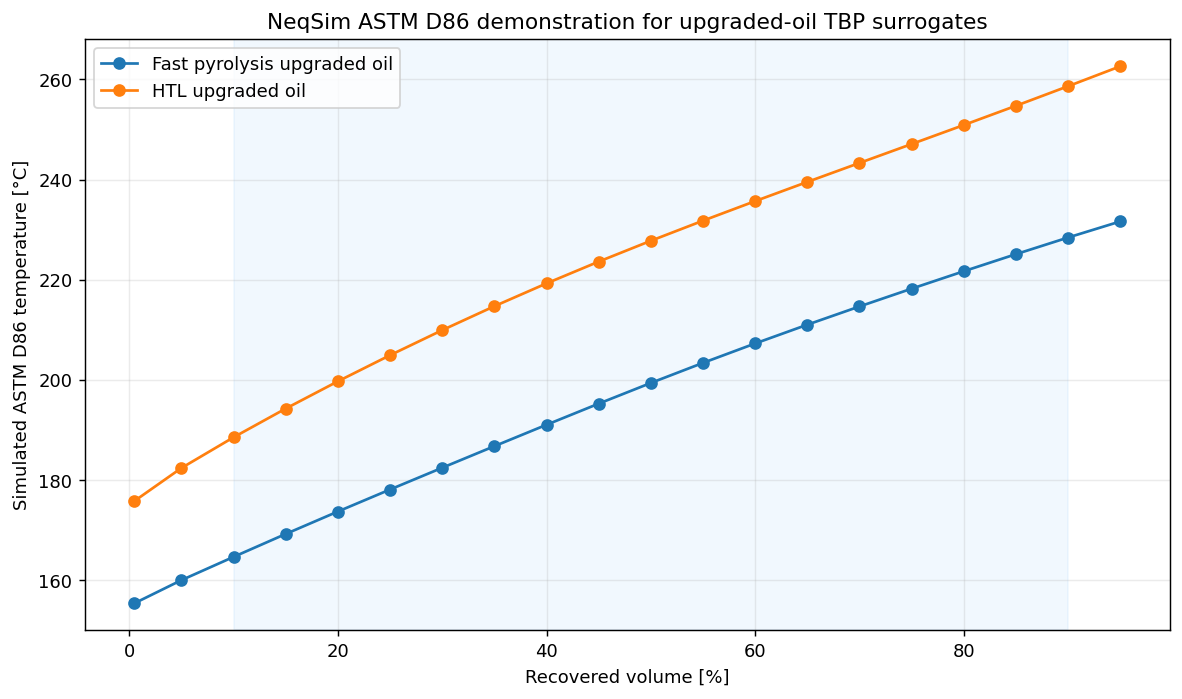

In [25]:
pyro_upgraded_tbp = [
    ("PY-C7", 0.15, 0.095, 0.72),
    ("PY-C10", 0.35, 0.135, 0.78),
    ("PY-C14", 0.35, 0.198, 0.82),
    ("PY-C18", 0.15, 0.254, 0.85),
]
htl_upgraded_tbp = [
    ("HTL-C7", 0.08, 0.095, 0.72),
    ("HTL-C10", 0.27, 0.135, 0.78),
    ("HTL-C14", 0.35, 0.198, 0.82),
    ("HTL-C18", 0.22, 0.254, 0.85),
    ("HTL-C22", 0.08, 0.310, 0.88),
]

pyro_quality, pyro_d86 = neqsim_oil_quality(pyro_upgraded_tbp)
htl_quality, htl_d86 = neqsim_oil_quality(htl_upgraded_tbp)
standards_quality = pd.DataFrame(
    [
        {"Route": "Fast pyrolysis upgraded oil", **pyro_quality},
        {"Route": "HTL upgraded oil", **htl_quality},
    ]
)
standards_quality["source_id"] = "SCN-NEQSIM-SURROGATE"
standards_quality["viscosity_status"] = np.where(
    standards_quality[["KV40_cSt", "KV100_cSt"]].notna().all(axis=1),
    "Calculated",
    "Needs a calibrated viscosity model / assay",
)
display(standards_quality.round(2))

pyro_d86["Route"] = "Fast pyrolysis upgraded oil"
htl_d86["Route"] = "HTL upgraded oil"
d86_curves = pd.concat([pyro_d86, htl_d86], ignore_index=True)

fig, ax = plt.subplots(figsize=(9.2, 5.5))
for route, route_curve in d86_curves.groupby("Route"):
    ax.plot(
        route_curve["recovered_vol_pct"],
        route_curve["temperature_C"],
        marker="o",
        label=route,
    )
ax.axvspan(10.0, 90.0, color="#90CAF9", alpha=0.12)
ax.set_xlabel("Recovered volume [%]")
ax.set_ylabel("Simulated ASTM D86 temperature [°C]")
ax.set_title("NeqSim ASTM D86 demonstration for upgraded-oil TBP surrogates")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


A blank viscosity result is informative rather than a numerical failure: the
simple TBP assay does not provide a validated viscosity model for these novel
upgraded bio-oils. Density, distillation, Watson K, and the documented smoke-
point estimate remain available, while ASTM D445 should be calibrated against
measured KV40/KV100 before it is used for design or certification.


In [26]:
tbp_input_records = []
for route, assay in [
    ("Fast pyrolysis upgraded oil", pyro_upgraded_tbp),
    ("HTL upgraded oil", htl_upgraded_tbp),
]:
    for name, amount, molar_mass, density in assay:
        tbp_input_records.append(
            [
                route,
                name,
                amount,
                molar_mass,
                density,
                "SCN-NEQSIM-SURROGATE",
            ]
        )
tbp_input_ledger = pd.DataFrame(
    tbp_input_records,
    columns=[
        "Route",
        "TBP fraction",
        "Relative molar amount",
        "Molar mass_kg_mol",
        "Specific gravity",
        "source_id",
    ],
)
display(tbp_input_ledger)


                      Route TBP fraction  Relative molar amount  Molar mass_kg_mol  Specific gravity            source_id
Fast pyrolysis upgraded oil        PY-C7                   0.15              0.095              0.72 SCN-NEQSIM-SURROGATE
Fast pyrolysis upgraded oil       PY-C10                   0.35              0.135              0.78 SCN-NEQSIM-SURROGATE
Fast pyrolysis upgraded oil       PY-C14                   0.35              0.198              0.82 SCN-NEQSIM-SURROGATE
Fast pyrolysis upgraded oil       PY-C18                   0.15              0.254              0.85 SCN-NEQSIM-SURROGATE
           HTL upgraded oil       HTL-C7                   0.08              0.095              0.72 SCN-NEQSIM-SURROGATE
           HTL upgraded oil      HTL-C10                   0.27              0.135              0.78 SCN-NEQSIM-SURROGATE
           HTL upgraded oil      HTL-C14                   0.35              0.198              0.82 SCN-NEQSIM-SURROGATE
           HTL upgraded 

## 14. Concept F — biogenic $CO_2$ plus electrolytic $H_2$

Fermentation, gasification cleanup, and upgrading can create concentrated
biogenic $CO_2$. Rather than release it, a hybrid plant can form CO by reverse
water-gas shift and then synthesize hydrocarbons:

$$CO_2+H_2\rightleftharpoons CO+H_2O$$

$$CO+2H_2\rightarrow -CH_2-+H_2O$$

Combining the ideal reactions gives approximately

$$CO_2+3H_2\rightarrow -CH_2-+2H_2O$$

The concept improves use of biogenic carbon but shifts the constraint toward
low-carbon electricity, electrolyzers, $CO_2$ purification, water, and capital.
It is therefore shown as a hybrid reference, not as a claim that power-to-liquid
is itself a biomass route.


In [27]:
captured_co2_kg = 600.0
hydrocarbon_kg = captured_co2_kg * 14.0 / 44.0
hydrogen_kg = captured_co2_kg * 6.0 / 44.0
water_kg = captured_co2_kg * 36.0 / 44.0
hybrid_saf_fraction = 0.70
hybrid_saf_kg = hydrocarbon_kg * hybrid_saf_fraction
electrolysis_kwh = hydrogen_kg * 52.0

print(f"Hydrocarbon potential: {hydrocarbon_kg:.1f} kg")
print(f"Stoichiometric hydrogen: {hydrogen_kg:.1f} kg")
print(f"Reaction water: {water_kg:.1f} kg")
print(f"SAF at 70 wt% of liquid product: {hybrid_saf_kg:.1f} kg")
print(f"Electrolysis electricity at 52 kWh/kg H₂: {electrolysis_kwh:.0f} kWh")


Hydrocarbon potential: 190.9 kg
Stoichiometric hydrogen: 81.8 kg
Reaction water: 490.9 kg
SAF at 70 wt% of liquid product: 133.6 kg
Electrolysis electricity at 52 kWh/kg H₂: 4255 kWh


## 15. Cross-route mass, carbon, hydrogen, and energy comparison

SAF-only energy efficiency is calculated here as SAF LHV divided by dry-feed
LHV plus imported hydrogen LHV, electricity, and heat. This penalizes a route
that deliberately makes valuable coproducts. A second metric includes all
hydrocarbon coproduct energy. Neither metric is a lifecycle result. The $H_2$
column is deliberately a mixed screening indicator: stoichiometric use for
HEFA, ATJ, and the hybrid; an explicit FT scenario; and only the oxygen-to-water
minimum for pyrolysis and HTL. It must not be read as a vendor consumption table.


          Route  SAF_yield_kg_per_t_dry  SAF_carbon_efficiency  SAF_energy_efficiency  Hydrocarbon_energy_efficiency  H2_kg
           HEFA                 517.366                  0.569                  0.523                          0.872 34.152
Gasification–FT                 240.000                  0.403                  0.472                          0.688  5.000
            ATJ                 129.847                  0.218                  0.251                          0.314  1.921
 Fast pyrolysis                 147.565                  0.258                  0.292                          0.531 22.400
            HTL                 225.588                  0.242                  0.352                          0.640  3.800
CO₂ + H₂ hybrid                 133.600                  0.693                  0.519                          0.741 81.800


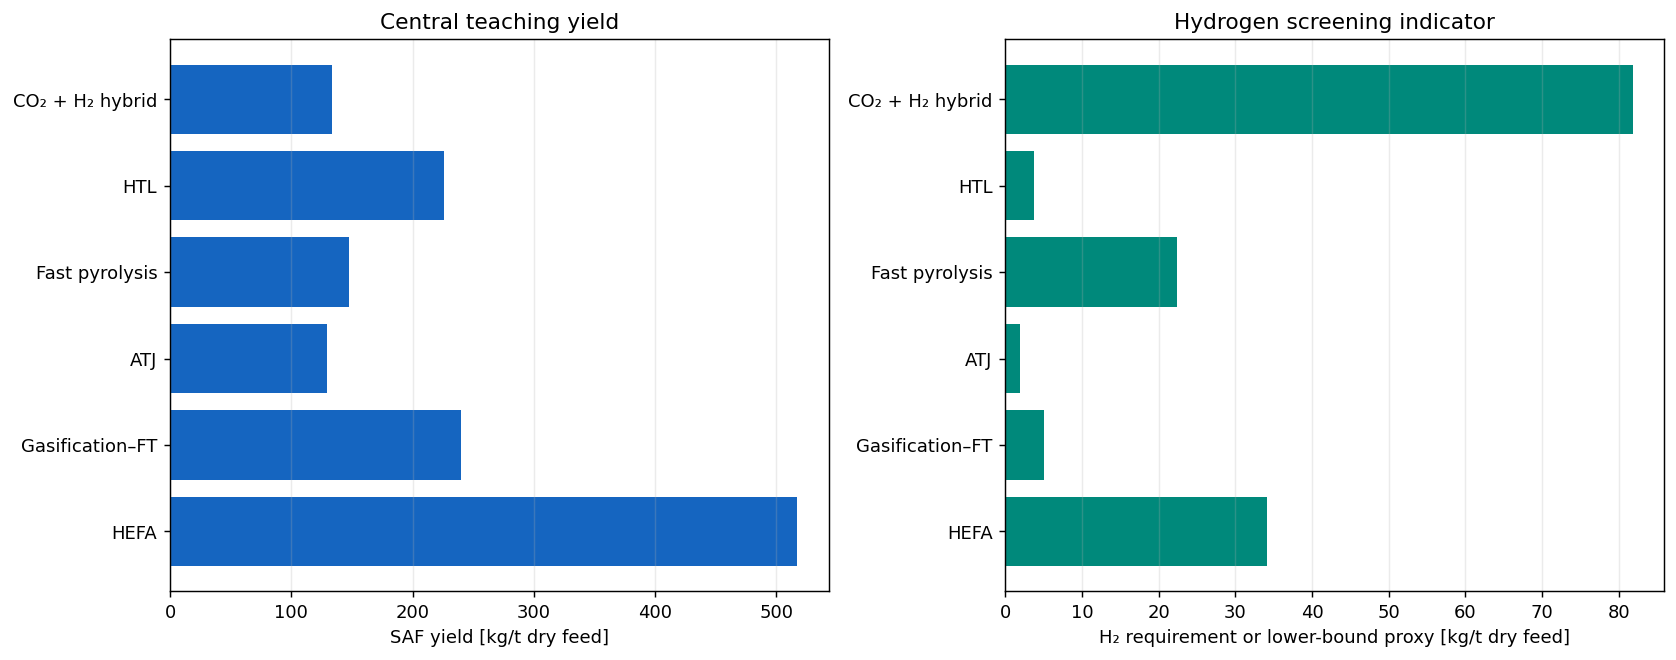

In [28]:
saf_lhv = 43.0
hydrogen_lhv = 120.0
route_data["Input_energy_GJ"] = (
    1000.0 * route_data["Feed_LHV_MJ_kg"]
    + route_data["H2_kg"] * hydrogen_lhv
    + route_data["Electricity_kWh"] * 3.6
    + route_data["Imported_heat_GJ"] * 1000.0
) / 1000.0
route_data["SAF_energy_efficiency"] = (
    route_data["SAF_kg"] * saf_lhv / 1000.0
) / route_data["Input_energy_GJ"]
route_data["Hydrocarbon_energy_efficiency"] = (
    (route_data["SAF_kg"] + route_data["Cofuel_kg"]) * saf_lhv / 1000.0
) / route_data["Input_energy_GJ"]
route_data.loc[
    route_data["Route"] == "HTL", "Hydrocarbon_energy_efficiency"
] = 0.64
route_data.loc[
    route_data["Route"] == "HTL", "SAF_energy_efficiency"
] = 0.64 * literature_to_saf_cut

comparison_columns = [
    "Route",
    "SAF_yield_kg_per_t_dry",
    "SAF_carbon_efficiency",
    "SAF_energy_efficiency",
    "Hydrocarbon_energy_efficiency",
    "H2_kg",
]
display(route_data[comparison_columns].round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].barh(route_data["Route"], route_data["SAF_kg"], color="#1565C0")
axes[0].set_xlabel("SAF yield [kg/t dry feed]")
axes[0].set_title("Central teaching yield")
axes[1].barh(route_data["Route"], route_data["H2_kg"], color="#00897B")
axes[1].set_xlabel("H₂ requirement or lower-bound proxy [kg/t dry feed]")
axes[1].set_title("Hydrogen screening indicator")
for axis in axes:
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


HEFA has the highest mass yield because the lipid feed is already energy-dense
and only moderately oxygenated. Lignocellulosic routes access a larger feedstock
pool but lose carbon to cleanup, fermentation, char, gas, and $CO_2$. The hybrid
route uses biogenic carbon efficiently only by importing much more hydrogen and
electricity. These are structural tradeoffs, not simply technology maturity.


## 16. Lifecycle intensity: use official values without confusing boundaries

ICAO defines

$$LCEF=\text{core LCA}+ILUC-\text{emission credits}$$

The values below are selected **default core LCA** examples from the November
2025 ICAO document, not final project $LCEF$ values. The fossil reference of
89 g $CO_2$e/MJ appears in ICAO's co-processing equations. Fast pyrolysis,
generic HTL, and the hybrid case are left unassigned because a concept name is
not a substitute for an eligible feedstock/process-specific entry.


          Route                Feedstock specification  Core_LCA_gCO2e_MJ        Source
Gasification–FT                      Forestry residues                8.3  ICAO table 1
           HEFA                       Used cooking oil               13.9  ICAO table 2
            ATJ Ethanol; forestry residues, integrated               24.9  ICAO table 4
 Fast pyrolysis                 Generic teaching route                NaN Case-specific
            HTL                 Generic teaching route                NaN Case-specific
CO₂ + H₂ hybrid                           Biogenic CO₂                NaN Case-specific


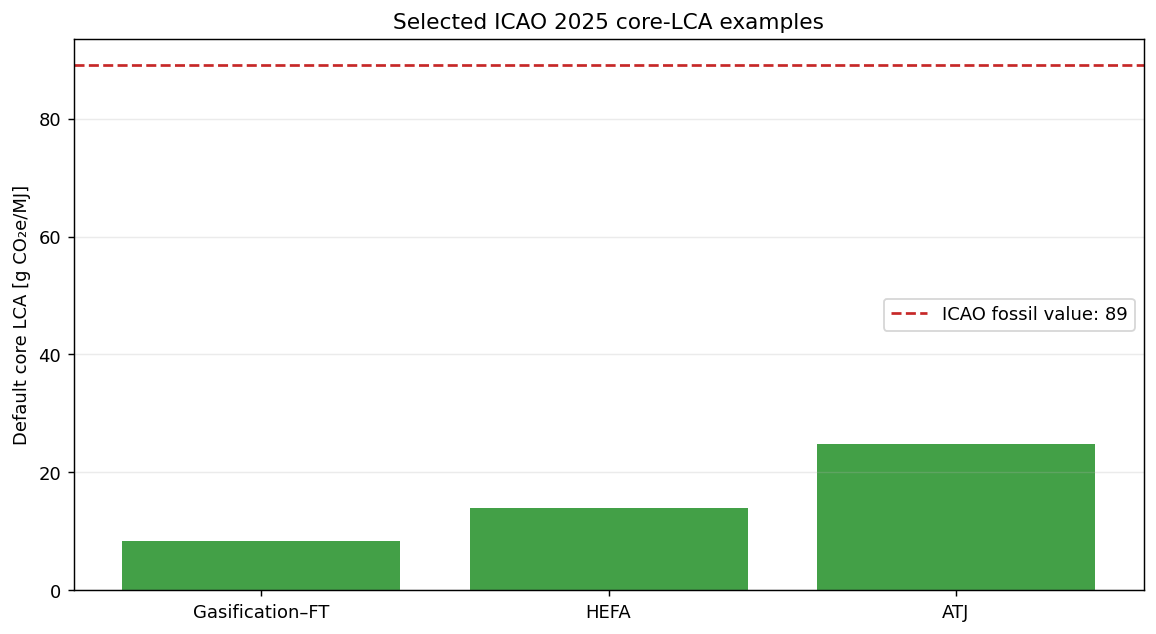

In [29]:
corsia_core = pd.DataFrame(
    [
        ["Gasification–FT", "Forestry residues", 8.3, "ICAO table 1"],
        ["HEFA", "Used cooking oil", 13.9, "ICAO table 2"],
        ["ATJ", "Ethanol; forestry residues, integrated", 24.9, "ICAO table 4"],
        ["Fast pyrolysis", "Generic teaching route", np.nan, "Case-specific"],
        ["HTL", "Generic teaching route", np.nan, "Case-specific"],
        ["CO₂ + H₂ hybrid", "Biogenic CO₂", np.nan, "Case-specific"],
    ],
    columns=["Route", "Feedstock specification", "Core_LCA_gCO2e_MJ", "Source"],
)
display(corsia_core)

plot_lca = corsia_core.dropna(subset=["Core_LCA_gCO2e_MJ"])
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_lca["Route"], plot_lca["Core_LCA_gCO2e_MJ"], color="#43A047")
ax.axhline(89.0, color="#C62828", linestyle="--", label="ICAO fossil value: 89")
ax.set_ylabel("Default core LCA [g CO₂e/MJ]")
ax.set_title("Selected ICAO 2025 core-LCA examples")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


A project calculation must add the applicable ILUC result and subtract only
eligible credits, following the current methodology. Electricity region,
hydrogen production, process heat, transport, coproduct allocation, soil carbon,
avoided waste emissions, non-biogenic municipal-waste carbon, and temporal
applicability can materially change the answer. GREET is valuable for scenario
analysis; CORSIA rules govern CORSIA claims.


## 17. Feedstock logistics and plant scale

Distributed low-density biomass creates a collection-area penalty. For a
circular supply region with recoverable areal density $q$,

$$R=\sqrt{\frac{M_{feed}}{\pi q}}$$

where $R$ is collection radius, $M_{feed}$ is annual dry feed, and $q$ is
recoverable dry feed per square kilometre per year. Real networks need road
factors, seasonal storage, moisture/ash penalties, competing uses, protected
land, supply risk, and multiple depots.


          Route  Dry_feed_t_y  Collection_radius_km
Gasification–FT      416666.7                  42.1
            ATJ      770138.8                  57.2
 Fast pyrolysis      677667.4                  53.6
            HTL      443286.2                  43.4


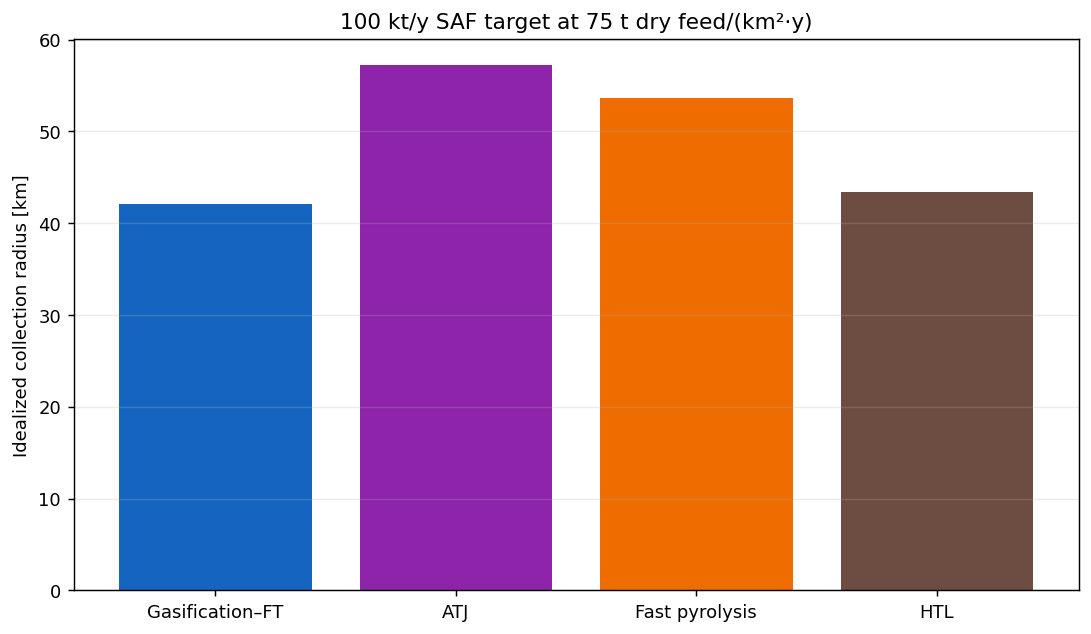

In [30]:
annual_saf_target_t = 100_000.0
recoverable_density_t_km2_y = 75.0
logistic_routes = route_data.loc[
    route_data["Route"].isin(
        ["Gasification–FT", "ATJ", "Fast pyrolysis", "HTL"]
    )
].copy()
logistic_routes["Dry_feed_t_y"] = (
    annual_saf_target_t * 1000.0 / logistic_routes["SAF_kg"]
)
logistic_routes["Collection_radius_km"] = np.sqrt(
    logistic_routes["Dry_feed_t_y"]
    / (math.pi * recoverable_density_t_km2_y)
)
display(
    logistic_routes[
        ["Route", "Dry_feed_t_y", "Collection_radius_km"]
    ].round(1)
)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(
    logistic_routes["Route"],
    logistic_routes["Collection_radius_km"],
    color=["#1565C0", "#8E24AA", "#EF6C00", "#6D4C41"],
)
ax.set_ylabel("Idealized collection radius [km]")
ax.set_title("100 kt/y SAF target at 75 t dry feed/(km²·y)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 18. Illustrative minimum selling price screen

This is a deliberately transparent annualized-cost screen, not a Class 4/5
estimate. Capital is expressed as euros per annual tonne of SAF capacity.
A 20-year, 8% real capital-recovery factor is applied. Feedstock, hydrogen,
and other variable costs are scenario assumptions; coproduct credits, taxes,
policy support, financing structure, escalation, owner costs, contingency, and
construction schedule are omitted.

$$CRF=\frac{i(1+i)^n}{(1+i)^n-1}$$

Two directly reported reference points help calibrate magnitude but must not be
compared as if harmonized: PNNL-24176 reports a 2014 fast-pyrolysis combined
fuel selling price of 5.26 USD/GGE, while PNNL-37230 reports 5.08 USD/GGE
(2020 dollars) for its HTL scenario 3 and 7.07 USD/GGE for scenario 6. Different
feedstocks, cost years, scale, coproducts, financing, and boundaries apply.


In [31]:
literature_tea = pd.DataFrame(
    [
        ["Fast pyrolysis", "2014 SOT", 5.26, "USD/GGE", "LIT-PNNL-PYRO-2014"],
        ["HTL", "2024 scenario 3", 5.08, "2020 USD/GGE", "LIT-PNNL-HTL-2024"],
        ["HTL", "2024 scenario 6", 7.07, "2020 USD/GGE", "LIT-PNNL-HTL-2024"],
    ],
    columns=["Route", "Reference case", "Reported value", "Basis", "source_id"],
)
display(literature_tea)


         Route  Reference case  Reported value        Basis          source_id
Fast pyrolysis        2014 SOT            5.26      USD/GGE LIT-PNNL-PYRO-2014
           HTL 2024 scenario 3            5.08 2020 USD/GGE  LIT-PNNL-HTL-2024
           HTL 2024 scenario 6            7.07 2020 USD/GGE  LIT-PNNL-HTL-2024


          Route  Illustrative_MSP_EUR_t  Illustrative_MSP_EUR_L
           HEFA                 2338.03                    1.87
Gasification–FT                 1204.82                    0.96
            ATJ                 1428.56                    1.14
 Fast pyrolysis                 1992.65                    1.59
            HTL                 1064.58                    0.85
CO₂ + H₂ hybrid                 3906.12                    3.12


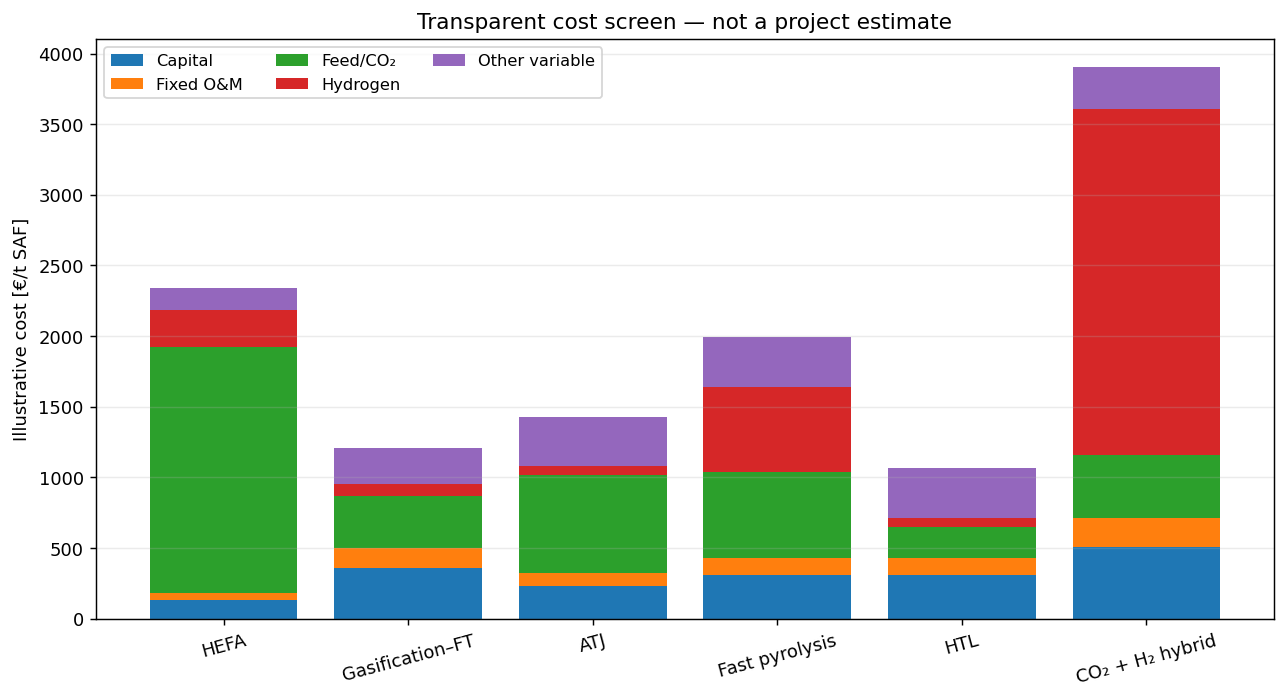

In [32]:
real_discount_rate = 0.08
project_life_y = 20
capital_recovery_factor = (
    real_discount_rate * (1.0 + real_discount_rate) ** project_life_y
) / ((1.0 + real_discount_rate) ** project_life_y - 1.0)

economics = pd.DataFrame(
    [
        ["HEFA", 1300.0, 900.0, 4.0, 150.0, "SCN-TEA"],
        ["Gasification–FT", 3500.0, 90.0, 4.0, 250.0, "SCN-TEA"],
        ["ATJ", 2300.0, 90.0, 4.0, 350.0, "SCN-TEA"],
        ["Fast pyrolysis", 3000.0, 90.0, 4.0, 350.0, "SCN-TEA"],
        ["HTL", 3000.0, 50.0, 4.0, 350.0, "SCN-TEA"],
        ["CO₂ + H₂ hybrid", 5000.0, 100.0, 4.0, 300.0, "SCN-TEA"],
    ],
    columns=[
        "Route",
        "CAPEX_EUR_per_annual_t_SAF",
        "Feed_or_CO2_EUR_t",
        "H2_EUR_kg",
        "Other_variable_EUR_t_SAF",
        "source_id",
    ],
)
economics = economics.merge(route_data[["Route", "SAF_kg", "H2_kg"]], on="Route")
economics["Feed_t_per_t_SAF"] = 1000.0 / economics["SAF_kg"]
economics.loc[
    economics["Route"] == "CO₂ + H₂ hybrid", "Feed_t_per_t_SAF"
] = 600.0 / 134.0
economics["H2_kg_per_t_SAF"] = 1000.0 * economics["H2_kg"] / economics["SAF_kg"]
economics["Annualized_CAPEX_EUR_t"] = (
    economics["CAPEX_EUR_per_annual_t_SAF"] * capital_recovery_factor
)
economics["Fixed_OM_EUR_t"] = 0.04 * economics["CAPEX_EUR_per_annual_t_SAF"]
economics["Feed_cost_EUR_t"] = (
    economics["Feed_t_per_t_SAF"] * economics["Feed_or_CO2_EUR_t"]
)
economics["H2_cost_EUR_t"] = (
    economics["H2_kg_per_t_SAF"] * economics["H2_EUR_kg"]
)
cost_columns = [
    "Annualized_CAPEX_EUR_t",
    "Fixed_OM_EUR_t",
    "Feed_cost_EUR_t",
    "H2_cost_EUR_t",
    "Other_variable_EUR_t_SAF",
]
economics["Illustrative_MSP_EUR_t"] = economics[cost_columns].sum(axis=1)
economics["Illustrative_MSP_EUR_L"] = (
    economics["Illustrative_MSP_EUR_t"] / 1000.0 * 0.80
)
display(
    economics[
        ["Route", "Illustrative_MSP_EUR_t", "Illustrative_MSP_EUR_L"]
    ].round(2)
)

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(economics))
labels = ["Capital", "Fixed O&M", "Feed/CO₂", "Hydrogen", "Other variable"]
for column, label in zip(cost_columns, labels):
    values = economics[column].to_numpy()
    ax.bar(economics["Route"], values, bottom=bottom, label=label)
    bottom = bottom + values
ax.set_ylabel("Illustrative cost [€/t SAF]")
ax.set_title("Transparent cost screen — not a project estimate")
ax.tick_params(axis="x", rotation=15)
ax.legend(ncol=3, fontsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


The screen illustrates structural sensitivities: HEFA is exposed to lipid
price; lignocellulosic routes to yield, feed logistics, and capital; fast
pyrolysis to bio-oil stabilization; HTL to aqueous treatment and plant scale;
and the hybrid route to hydrogen/electricity.
A lower-cost route in this table is not automatically more sustainable,
bankable, certifiable, or scalable.


## 19. Uncertainty: avoid ranking routes by single-point precision

A Monte Carlo screen varies SAF yield, CAPEX, feed price, and hydrogen price.
It is intentionally simple but demonstrates how nonlinear feed-per-product
ratios widen the cost distribution when yield is uncertain.


   P10    P50    P90
1904.0 2362.0 2957.0
1063.0 1218.0 1414.0
1246.0 1439.0 1683.0
1715.0 2007.0 2344.0
 953.0 1074.0 1217.0
3074.0 3917.0 4855.0


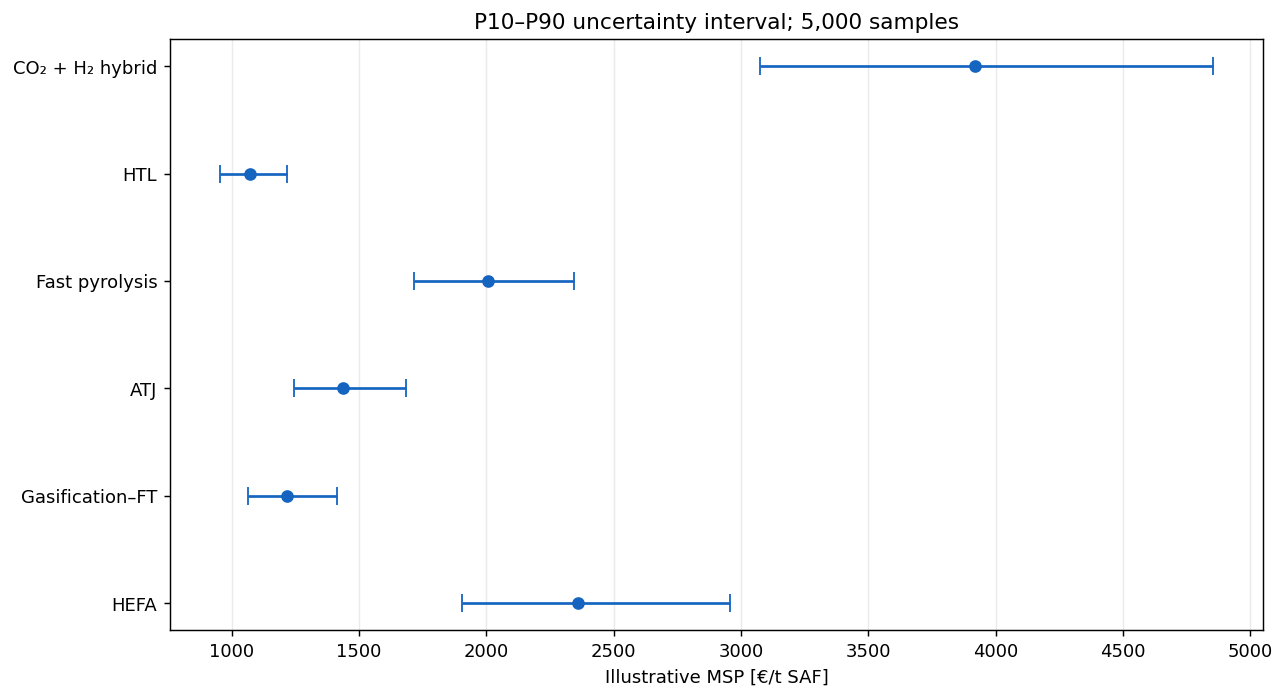

In [33]:
rng = np.random.default_rng(20260820)
samples = 5000
uncertainty_records = []
central_yield = economics.set_index("Route")["SAF_kg"]

for _, row in economics.iterrows():
    route = row["Route"]
    yield_samples = rng.normal(central_yield[route], 0.10 * central_yield[route], samples)
    yield_samples = np.clip(yield_samples, 0.55 * central_yield[route], None)
    capex_samples = row["CAPEX_EUR_per_annual_t_SAF"] * rng.lognormal(
        mean=0.0, sigma=0.20, size=samples
    )
    feed_samples = row["Feed_or_CO2_EUR_t"] * rng.lognormal(
        mean=0.0, sigma=0.20, size=samples
    )
    hydrogen_price = np.clip(rng.normal(row["H2_EUR_kg"], 1.0, samples), 1.0, None)
    feed_ratio = 1000.0 / yield_samples
    if route == "CO₂ + H₂ hybrid":
        feed_ratio = np.full(samples, 600.0 / 134.0)
    hydrogen_ratio = 1000.0 * row["H2_kg"] / yield_samples
    msp = (
        capex_samples * capital_recovery_factor
        + 0.04 * capex_samples
        + feed_ratio * feed_samples
        + hydrogen_ratio * hydrogen_price
        + row["Other_variable_EUR_t_SAF"]
    )
    for percentile, value in zip(
        [10, 50, 90], np.percentile(msp, [10, 50, 90])
    ):
        uncertainty_records.append([route, percentile, value])

uncertainty = pd.DataFrame(
    uncertainty_records,
    columns=["Route", "Percentile", "MSP_EUR_t"],
)
uncertainty_pivot = uncertainty.pivot(
    index="Route", columns="Percentile", values="MSP_EUR_t"
).loc[economics["Route"]]
display(uncertainty_pivot.round(0).rename(columns={10: "P10", 50: "P50", 90: "P90"}))

fig, ax = plt.subplots(figsize=(10, 5.5))
medians = uncertainty_pivot[50]
lower = medians - uncertainty_pivot[10]
upper = uncertainty_pivot[90] - medians
ax.errorbar(
    medians,
    uncertainty_pivot.index,
    xerr=np.vstack([lower, upper]),
    fmt="o",
    capsize=5,
    color="#1565C0",
)
ax.set_xlabel("Illustrative MSP [€/t SAF]")
ax.set_title("P10–P90 uncertainty interval; 5,000 samples")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## 20. Multi-criteria decision screen

A route decision should not collapse to yield or cost alone. The scores below
are `SCN-DECISION` teaching judgements from 1 (weak) to 5 (strong), not
literature observations. Change both the scores and weights for a location,
feedstock portfolio, refinery integration, policy regime, and objective.


 Maturity  Feedstock scale  Carbon efficiency  Lifecycle potential  Cost potential  Integration fit  Weighted score
        5                2                  4                    4               3                5            3.75
        3                5                  3                    5               3                3            3.80
        3                4                  2                    3               3                4            3.15
        2                4                  3                    3               2                3            2.85
        2                4                  3                    3               2                3            2.85
        2                3                  4                    5               1                3            3.05


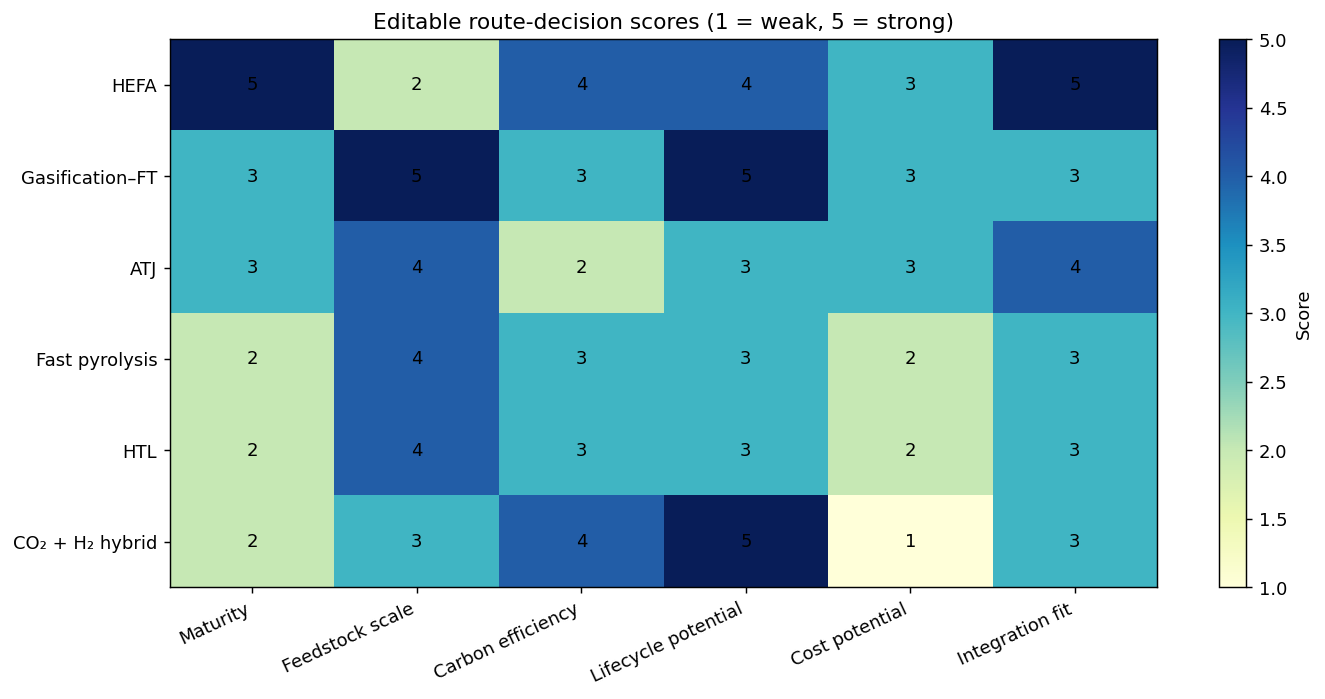

In [34]:
criteria = [
    "Maturity",
    "Feedstock scale",
    "Carbon efficiency",
    "Lifecycle potential",
    "Cost potential",
    "Integration fit",
]
weights = pd.Series(
    [0.20, 0.20, 0.15, 0.20, 0.15, 0.10],
    index=criteria,
    name="Weight",
)
scores = pd.DataFrame(
    [
        [5, 2, 4, 4, 3, 5],
        [3, 5, 3, 5, 3, 3],
        [3, 4, 2, 3, 3, 4],
        [2, 4, 3, 3, 2, 3],
        [2, 4, 3, 3, 2, 3],
        [2, 3, 4, 5, 1, 3],
    ],
    index=route_data["Route"],
    columns=criteria,
)
weighted_score = scores.mul(weights, axis=1).sum(axis=1).sort_values(ascending=False)
display(pd.concat([scores, weighted_score.rename("Weighted score")], axis=1).round(2))

fig, ax = plt.subplots(figsize=(11, 5.5))
image = ax.imshow(scores, cmap="YlGnBu", vmin=1, vmax=5, aspect="auto")
ax.set_xticks(np.arange(len(criteria)), labels=criteria, rotation=25, ha="right")
ax.set_yticks(np.arange(len(scores.index)), labels=scores.index)
for row in range(scores.shape[0]):
    for column in range(scores.shape[1]):
        ax.text(column, row, scores.iloc[row, column], ha="center", va="center")
ax.set_title("Editable route-decision scores (1 = weak, 5 = strong)")
fig.colorbar(image, ax=ax, label="Score")
plt.tight_layout()
plt.show()


## 21. Programmatic external-data access pattern

The safest workflow is: download a versioned raw file; save it unchanged with
licence and checksum; transform it in a separate step; validate units and bases;
and export a small, cited model-input table. Live endpoints should not be the
only way to reproduce an engineering study.


In [35]:
data_catalog = pd.DataFrame(
    [
        ["Phyllis2", "HTML/export", "Ultimate/proximate analysis", "Manual/API-dependent"],
        ["JRC ENSPRESO", "XLSX", "Regional biomass potential", "Anonymous download"],
        ["FAOSTAT", "CSV/API", "Production and trade", "Public"],
        ["Eurostat", "JSON-stat/SDMX", "EU statistics and prices", "Public"],
        ["R&D GREET", "Versioned model DB", "Lifecycle inventories", "Check licence/version"],
        ["ICAO CORSIA", "PDF tables", "Eligibility and default LCA", "Controlled methodology"],
    ],
    columns=["Dataset", "Format", "Model role", "Access note"],
)

external_urls = {
    "jrc_enspreso": (
        "https://data.jrc.ec.europa.eu/dataset/"
        "74ed5a04-7d74-4807-9eab-b94774309d9f"
    ),
    "eurostat_api_docs": (
        "https://ec.europa.eu/eurostat/web/user-guides/"
        "data-browser/api-data-access/api-getting-started"
    ),
    "faostat": "https://www.fao.org/faostat/en/",
    "greet_versions": "https://greet.anl.gov/greet/versions.html",
    "phyllis2": "https://phyllis.nl/",
}

def normalize_ultimate_analysis(frame, basis_columns):
    normalized = frame.copy()
    total = normalized[basis_columns].sum(axis=1)
    normalized[basis_columns] = normalized[basis_columns].div(total, axis=0) * 100.0
    normalized["normalization_factor"] = 100.0 / total
    return normalized

display(data_catalog)
print("External endpoints recorded:")
for name, url in external_urls.items():
    print(f"- {name}: {url}")


     Dataset             Format                  Model role            Access note
    Phyllis2        HTML/export Ultimate/proximate analysis   Manual/API-dependent
JRC ENSPRESO               XLSX  Regional biomass potential     Anonymous download
     FAOSTAT            CSV/API        Production and trade                 Public
    Eurostat     JSON-stat/SDMX    EU statistics and prices                 Public
   R&D GREET Versioned model DB       Lifecycle inventories  Check licence/version
 ICAO CORSIA         PDF tables Eligibility and default LCA Controlled methodology
External endpoints recorded:
- jrc_enspreso: https://data.jrc.ec.europa.eu/dataset/74ed5a04-7d74-4807-9eab-b94774309d9f
- eurostat_api_docs: https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-getting-started
- faostat: https://www.fao.org/faostat/en/
- greet_versions: https://greet.anl.gov/greet/versions.html
- phyllis2: https://phyllis.nl/


## 22. What NeqSim does—and does not—cover in this study

**Strong applications in an integrated SAF model**

- syngas, hydrogen, $CO_2$, water, and light-hydrocarbon phase behavior;
- cooling, condensation, three-phase separation, compression, valves, pumps,
  heat exchangers, recycle loops, and utility estimates;
- surrogate product assays and property trends across operating cases;
- connection of process streams to larger hydrogen, $CO_2$, or refinery models.

**Models that should remain external or be specially developed/validated**

- non-conventional solid biomass enthalpy, drying, devolatilization, and ash;
- gasifier kinetics, tar/char/slag, contaminant cleanup, and oxygen plant detail;
- FT, hydrotreating, fermentation, oligomerization, and deactivation kinetics;
- rigorous refinery assays, distillation curves, cold-flow and combustion tests;
- ASTM qualification, CORSIA certification, lifecycle inventory, and finance.

A good architecture passes explicit, conserved stream tables between these
specialist models instead of forcing every phenomenon into one simulator.


In [36]:
surrogate_streams = {
    "HEFA upgrading effluent": hefa_surrogate,
    "Raw wet syngas": raw_syngas,
    "Clean compressor syngas": clean_syngas,
    "ATJ upgrading effluent": atj_surrogate,
    "Fast-pyrolysis upgrading effluent": pyro_upgrade_surrogate,
    "HTL upgrading effluent": htl_upgrade_surrogate,
}
surrogate_records = []
for stream_name, assay in surrogate_streams.items():
    for component, amount in assay.items():
        surrogate_records.append(
            [
                stream_name,
                component,
                amount,
                "relative molar amount",
                "SCN-NEQSIM-SURROGATE",
            ]
        )
surrogate_input_ledger = pd.DataFrame(
    surrogate_records,
    columns=["stream", "component", "value", "unit", "source_id"],
)
display(surrogate_input_ledger)


                           stream component  value                  unit            source_id
          HEFA upgrading effluent  hydrogen   20.0 relative molar amount SCN-NEQSIM-SURROGATE
          HEFA upgrading effluent   propane    8.0 relative molar amount SCN-NEQSIM-SURROGATE
          HEFA upgrading effluent       CO2    5.0 relative molar amount SCN-NEQSIM-SURROGATE
          HEFA upgrading effluent     water   15.0 relative molar amount SCN-NEQSIM-SURROGATE
          HEFA upgrading effluent n-heptane    5.0 relative molar amount SCN-NEQSIM-SURROGATE
          HEFA upgrading effluent      nC10   35.0 relative molar amount SCN-NEQSIM-SURROGATE
          HEFA upgrading effluent      nC16   12.0 relative molar amount SCN-NEQSIM-SURROGATE
                   Raw wet syngas        H2   42.0 relative molar amount SCN-NEQSIM-SURROGATE
                   Raw wet syngas        CO   34.0 relative molar amount SCN-NEQSIM-SURROGATE
                   Raw wet syngas       CO2   10.0 relative 

## 23. Validation checks

The checks below test numerical and physical consistency achieved in the
notebook. Passing them does not validate the illustrative yield assumptions
against a commercial plant.


In [37]:
validation_checks = {
    "feedstock dry sums within 0.2 wt%": bool(
        np.all(np.abs(feedstocks["Dry_sum_wt"] - 100.0) < 0.2)
    ),
    "HEFA total mass balance closes": abs(hefa_mass_error) < 1.0e-9,
    "ATJ upgrading mass balance closes": abs(atj_mass_residual) < 1.0e-9,
    "Pyrolysis primary mass balance closes": abs(pyro_mass_residual) < 1.0e-9,
    "HTL scenario 3 mass balance closes": abs(htl_residual) < 1.0e-9,
    "HTL experimental rounding gap is 1 wt%": abs(htl_reported_sum - 99.0) < 1.0e-9,
    "HEFA flash has gas/oil/aqueous phases": set(hefa_flash["phase"])
    == {"gas", "oil", "aqueous"},
    "ATJ flash has gas/oil/aqueous phases": set(atj_flash["phase"])
    == {"gas", "oil", "aqueous"},
    "pyrolysis surrogate has oil and aqueous phases": {
        "oil",
        "aqueous",
    }.issubset(set(pyro_upgrade_flash["phase"])),
    "HTL surrogate has oil and aqueous phases": {
        "oil",
        "aqueous",
    }.issubset(set(htl_upgrade_flash["phase"])),
    "syngas flash condenses an aqueous phase": "aqueous"
    in set(syngas_flash["phase"]),
    "three-stage compression uses less power": three_stage_power < one_stage_power,
    "core oil-quality standard outputs are finite": bool(
        np.isfinite(
            standards_quality[
                [
                    "density_15C_kg_m3",
                    "API_gravity",
                    "IBP_C",
                    "T10_C",
                    "T50_C",
                    "T90_C",
                    "FBP_C",
                    "Watson_K",
                    "smoke_point_mm_estimate",
                ]
            ].to_numpy()
        ).all()
    ),
    "D86 curves rise with recovered volume": bool(
        all(
            np.all(np.diff(curve["temperature_C"]) >= -1.0e-8)
            for _, curve in d86_curves.groupby("Route")
        )
    ),
    "all carbon efficiencies are physical": bool(
        route_data["SAF_carbon_efficiency"].between(0.0, 1.0).all()
    ),
    "all energy efficiencies are physical": bool(
        route_data["Hydrocarbon_energy_efficiency"].between(0.0, 1.0).all()
    ),
    "Monte Carlo outputs are finite": bool(np.isfinite(uncertainty["MSP_EUR_t"]).all()),
}
validation_table = pd.DataFrame(
    validation_checks.items(), columns=["Check", "Passed"]
)
display(validation_table)
if not validation_table["Passed"].all():
    raise AssertionError("One or more notebook validation checks failed.")
print("All stored calculation checks passed.")


                                         Check  Passed
             feedstock dry sums within 0.2 wt%    True
                HEFA total mass balance closes    True
             ATJ upgrading mass balance closes    True
         Pyrolysis primary mass balance closes    True
            HTL scenario 3 mass balance closes    True
        HTL experimental rounding gap is 1 wt%    True
         HEFA flash has gas/oil/aqueous phases    True
          ATJ flash has gas/oil/aqueous phases    True
pyrolysis surrogate has oil and aqueous phases    True
      HTL surrogate has oil and aqueous phases    True
       syngas flash condenses an aqueous phase    True
       three-stage compression uses less power    True
  core oil-quality standard outputs are finite    True
         D86 curves rise with recovered volume    True
          all carbon efficiencies are physical    True
          all energy efficiencies are physical    True
                Monte Carlo outputs are finite    True
All stored

## 24. Results summary

The following compact table keeps the central teaching assumptions beside the
decision-relevant outputs. Read it together with the uncertainty and limitation
sections rather than as a technology leaderboard.


In [38]:
summary = route_data[
    [
        "Route",
        "SAF_kg",
        "H2_kg",
        "SAF_carbon_efficiency",
        "SAF_energy_efficiency",
    ]
].merge(
    economics[["Route", "Illustrative_MSP_EUR_L"]],
    on="Route",
)
summary = summary.merge(
    weighted_score.rename("Decision_score"),
    left_on="Route",
    right_index=True,
)
summary = summary.merge(
    corsia_core[["Route", "Core_LCA_gCO2e_MJ"]],
    on="Route",
    how="left",
)
display(summary.round(3))

oil_yield_quality_summary = pd.DataFrame(
    [
        [
            "Fast pyrolysis",
            65.0,
            21.0,
            36.0,
            pyro_total_fuel,
            pyro_saf,
            pyro_quality["density_15C_kg_m3"],
            pyro_quality["T50_C"],
            pyro_quality["smoke_point_mm_estimate"],
        ],
        [
            "HTL",
            34.0,
            26.0,
            8.9,
            htl_total_fuel,
            htl_saf,
            htl_quality["density_15C_kg_m3"],
            htl_quality["T50_C"],
            htl_quality["smoke_point_mm_estimate"],
        ],
    ],
    columns=[
        "Route",
        "Primary_oil_yield_wt_pct",
        "Raw_oil_water_wt_pct",
        "Raw_dry_oil_oxygen_wt_pct",
        "Finished_fuel_kg_t",
        "Scenario_SAF_kg_t",
        "Upgraded_surrogate_density_kg_m3",
        "Upgraded_surrogate_D86_T50_C",
        "Upgraded_surrogate_smoke_point_mm",
    ],
)
display(oil_yield_quality_summary.round(2))


          Route  SAF_kg  H2_kg  SAF_carbon_efficiency  SAF_energy_efficiency  Illustrative_MSP_EUR_L  Decision_score  Core_LCA_gCO2e_MJ
           HEFA 517.366 34.152                  0.569                  0.523                   1.870            3.75               13.9
Gasification–FT 240.000  5.000                  0.403                  0.472                   0.964            3.80                8.3
            ATJ 129.847  1.921                  0.218                  0.251                   1.143            3.15               24.9
 Fast pyrolysis 147.565 22.400                  0.258                  0.292                   1.594            2.85                NaN
            HTL 225.588  3.800                  0.242                  0.352                   0.852            2.85                NaN
CO₂ + H₂ hybrid 133.600 81.800                  0.693                  0.519                   3.125            3.05                NaN
         Route  Primary_oil_yield_wt_pct  Raw_oi

## 25. Conclusions

- **HEFA** is the most mature and has high yield, but sustainable low-CI lipid
  supply is limited and feed price dominates.
- **Gasification–FT** can use broad lignocellulosic and waste resources and has
  strong lifecycle potential, but cleanup, integration, capital, and feed
  logistics are demanding. NeqSim shows why water removal and staged syngas
  compression matter.
- **ATJ** benefits from modular alcohol supply and approved routes, but the
  biomass-to-alcohol step, heat integration, and carbon losses control the full
  chain.
- **Fast pyrolysis** converts relatively dry lignocellulose to bio-oil, char,
  gas, and water. Liquid stabilization, deep deoxygenation, hydrogen supply,
  and proving an aviation-range qualified product are central risks.
- **HTL** accepts wet feed and forms a less oxygenated but often N-rich
  biocrude plus a large aqueous-organic stream, gas, and solids. High-pressure
  slurry handling, aqueous treatment, scale, upgrading, and route-specific
  qualification are decisive.
- **Biogenic $CO_2$ plus green $H_2$** can recover carbon otherwise lost, but
  electricity and hydrogen dominate the scale and cost.

The robust project workflow is to screen regional feedstocks first, carry a
consistent carbon/energy basis into process models, validate each specialist
conversion model, use NeqSim for the conventional-fluid and equipment network,
and only then connect the result to a versioned LCA and economic model.


## 26. Suggested extensions

1. Replace forestry-residue data with a cited Norwegian feedstock distribution
   and propagate moisture, ash, chlorine, alkali, and transport uncertainty.
2. Add an oxygen plant, steam balance, syngas cleanup pressure drop, FT recycle,
   purge, and heat-recovery steam system.
3. Compare cobalt and iron FT loops at different $H_2/CO$ ratios and carbon
   conversions, while enforcing overall carbon conservation.
4. Couple cellulosic ethanol production and ATJ upgrading with integrated and
   standalone heat balances matching the ICAO definitions.
5. Replace the hydrocarbon surrogates with a measured simulated-distillation
   assay and validate density, viscosity, flash point, and freezing-point trends.
6. Import versioned GREET and ENSPRESO extracts, then compare Norway, EU average,
   and renewable-power scenarios.
7. Build a portfolio optimizer that constrains lipid supply, biomass collection,
   renewable electricity, hydrogen, capital, and annual SAF demand.
